# 📈 Attention Meta-Learner — MOEX Si
**ВКР | Финансовый университет | Прикладное машинное обучение**

> Адаптивный ансамбль с механизмом внимания для краткосрочного прогнозирования цен на высокочастотных данных Московской биржи.

In [1]:
import warnings
warnings.filterwarnings('ignore')

---
## 0. Подключение библиотек
Стандартные библиотеки, визуализация, эконометрика, ML-фреймворки и утилиты.

In [2]:
# ── Стандартные библиотеки ──
import numpy as np
import pandas as pd
from datetime import timedelta
from itertools import combinations

# ── Визуализация ──
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# ── Статистика и эконометрика ──
from scipy import stats
from scipy.stats import jarque_bera, kurtosis, skew
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model

# ── Машинное обучение ──
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score,
                              precision_score, recall_score, f1_score)
from sklearn.model_selection import TimeSeriesSplit

# ── Градиентный бустинг ──
from catboost import CatBoostClassifier, Pool
import lightgbm as lgb
import xgboost as xgb
import shap

# ── Глубокое обучение (PyTorch) ──
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ── Утилиты ──
from tqdm import tqdm
# ── Дополнительные метрики ──
from sklearn.metrics import average_precision_score, log_loss, brier_score_loss


---
## 1. Настройка окружения
Визуальный стиль в стиле quant-research, фиксация seed для воспроизводимости.

In [3]:
# ── Настройка визуального стиля (Quant Research) ──
plt.style.use('dark_background')
COLORS = {
    'ensemble': '#00ff9d',
    'catboost': '#ff9900',
    'mamba':    '#44aaff',
    'kan':      '#ff44aa',
    'bh':       '#888888',
    'accent':   '#ffe066',
    'bg':       '#0d1117',
}
sns.set_palette([COLORS['ensemble'], COLORS['catboost'], COLORS['mamba'],
                 COLORS['kan'], COLORS['bh']])

# ── Воспроизводимость ──
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("✅ Все библиотеки успешно импортированы")
print(f"   PyTorch: {torch.__version__} | CUDA: {torch.cuda.is_available()}")
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"   Устройство для обучения: {DEVICE.upper()}")

✅ Все библиотеки успешно импортированы
   PyTorch: 2.11.0+cpu | CUDA: False
   Устройство для обучения: CPU


---
## 2. Загрузка и предобработка данных
Фьючерс **Si (USD/RUB)**, MOEX FORTS, минутный таймфрейм.
Фильтрация торговых сессий, очистка, Feature Engineering (27 микроструктурных признаков).

In [4]:
FILE_PATH = '../data/Si_1min_2025-05-02_2026-04-30.csv'

print("📂 Загрузка данных MOEX FORTS (фьючерс Si, M1)...")
df_raw = pd.read_csv(FILE_PATH, sep=';', header=0)
df_raw.columns = ['Ticker', 'Period', 'Date', 'Time',
                   'Open', 'High', 'Low', 'Close', 'Volume', 'OpenInt']

df_raw['Datetime'] = pd.to_datetime(
    df_raw['Date'].astype(str) + df_raw['Time'].astype(str).str.zfill(6),
    format='%Y%m%d%H%M%S'
)
df_raw.set_index('Datetime', inplace=True)
df_raw = df_raw.sort_index()

print(f"   Период: {df_raw.index.min().date()} → {df_raw.index.max().date()}")
print(f"   Записей: {len(df_raw):,} минутных баров")
print(f"   Торговых дней: {df_raw.index.normalize().nunique()}")
print(f"   Пропущенных значений: {df_raw.isnull().sum().sum()}")
print()

# ════════════════════════════════════════════════════════════════
# 2.2 ФИЛЬТРАЦИЯ ТОРГОВЫХ СЕССИЙ И ОЧИСТКА
# ════════════════════════════════════════════════════════════════
# Отсекаем ночной клиринг и технические перерывы MOEX
df = df_raw.copy()
df = df[(df.index.time >= pd.Timestamp('09:00').time()) &
        (df.index.time <= pd.Timestamp('23:49').time())]

# Удаляем нулевые объёмы (технические бары)
df = df[df['Volume'] > 0]
print(f"   После фильтрации сессий: {len(df):,} баров")

# ════════════════════════════════════════════════════════════════
# 2.3 МИКРОСТРУКТУРНЫЙ FEATURE ENGINEERING
# ════════════════════════════════════════════════════════════════
print("⚙️  Генерация микроструктурных признаков...")

# ─ 1. Логарифмические доходности (обеспечивают стационарность) ─
df['Log_Ret'] = np.log(df['Close'] / df['Close'].shift(1))

# ─ 2. Realized Volatility — скользящая 15-минутная волатильность ─
# Формула: RV_T = sqrt(sum(r_i^2)), i in [t-T, t]
df['RV_15m'] = df['Log_Ret'].rolling(window=15).apply(
    lambda x: np.sqrt(np.sum(x**2)), raw=True
)

# ─ 3. Аппроксимация спреда Corwin-Schultz (через High/Low) ─
# β = [log(H/L)_t]^2 + [log(H/L)_{t+1}]^2
# γ = [log(max(H_t, H_{t+1}) / min(L_t, L_{t+1}))]^2
hl = np.log(df['High'] / df['Low'])
beta = hl**2 + hl.shift(1)**2
gamma = np.log(df[['High']].rolling(2).max().values.flatten() /
               df[['Low']].rolling(2).min().values.flatten()) ** 2
alpha = (np.sqrt(2 * beta) - np.sqrt(beta)) / (3 - 2*np.sqrt(2)) - np.sqrt(gamma / (3 - 2*np.sqrt(2)))
df['Sim_Spread'] = 2 * (np.exp(pd.Series(alpha, index=df.index)) - 1)
df['Sim_Spread'] = df['Sim_Spread'].clip(lower=0).rolling(3).mean()

# Резервный вариант (High-Low) если Corwin-Schultz даёт NaN
df['Sim_Spread'] = df['Sim_Spread'].fillna((df['High'] - df['Low']) / df['Close'] * 10000)

# ─ 4. Order Book Imbalance — давление агрессивных заявок ─
# OBI > 0 → преобладают покупатели, OBI < 0 → продавцы
df['Raw_OBI'] = ((df['Close'] - df['Open']) /
                  (df['High'] - df['Low'] + 1e-8)) * np.log1p(df['Volume'])
df['OBI'] = df['Raw_OBI'].rolling(3).mean()

# ─ 5. Micro-Price — взвешенная эффективная цена внутри спреда ─
# P_micro = (P_ask * V_bid + P_bid * V_ask) / (V_bid + V_ask)
# Аппроксимируем через High/Low как proxy P_ask / P_bid
df['Micro_Price'] = (df['High'] * df['Volume'].rolling(2).sum().shift(1) +
                      df['Low'] * df['Volume'].rolling(2).sum()) / \
                     (df['Volume'].rolling(2).sum().shift(1) + df['Volume'].rolling(2).sum() + 1e-8)

# ─ 6. Моментум-признаки (лаги доходности) ─
for i in range(1, 6):
    df[f'Ret_Lag_{i}'] = df['Log_Ret'].shift(i)

# ─ 7. Дополнительные технические индикаторы ─
# RSI (14 периодов)
delta = df['Log_Ret']
gain = delta.clip(lower=0).rolling(14).mean()
loss = (-delta).clip(lower=0).rolling(14).mean()
df['RSI_14'] = 100 - (100 / (1 + gain / (loss + 1e-8)))

# EMA-разрыв (быстрая/медленная скользящие)
ema_fast = df['Close'].ewm(span=5).mean()
ema_slow = df['Close'].ewm(span=20).mean()
df['EMA_Spread'] = (ema_fast - ema_slow) / df['Close'] * 100

# Внутридневная сезонность (час торговой сессии как признак)
df['Session_Hour'] = df.index.hour + df.index.minute / 60

# ─ 8. Скользящий Z-Score (нормализация) ─
# Обеспечивает одинаковую значимость всех признаков
for col in ['RV_15m', 'OBI', 'Sim_Spread', 'Micro_Price', 'RSI_14']:
    roll_mean = df[col].rolling(window=60).mean()
    roll_std  = df[col].rolling(window=60).std() + 1e-8
    df[f'{col}_Z'] = (df[col] - roll_mean) / roll_std

df = df.dropna()
print(f"   Признаков сконструировано: {len(df.columns)} | Чистых баров: {len(df):,}")

📂 Загрузка данных MOEX FORTS (фьючерс Si, M1)...
   Период: 2025-05-02 → 2026-04-30
   Записей: 219,529 минутных баров
   Торговых дней: 253
   Пропущенных значений: 0

   После фильтрации сессий: 219,279 баров
⚙️  Генерация микроструктурных признаков...
   Признаков сконструировано: 29 | Чистых баров: 219,205


---
## 3. Разведочный анализ (EDA) — Стилизованные факты
ADF-тест, тест Жака-Бера, Q-Q plot, ACF квадратов доходностей (ARCH-эффект), внутридневная сезонность волатильности.

📊 Статистический анализ временного ряда доходностей...
\n  [ADF-тест] Статистика: -104.4600 | p-value: 0.000000
  → Доходности СТАЦИОНАРНЫ (α=5%)
\n  [Жак-Бера] Статистика: 60668117874.13 | p-value: 0.00e+00
  Эксцесс (Kurt): 2579.9194 (нормальное = 3)
  Асимметрия (Skew): 21.3854
  → Распределение НЕ нормальное (leptokurtosis подтверждена)


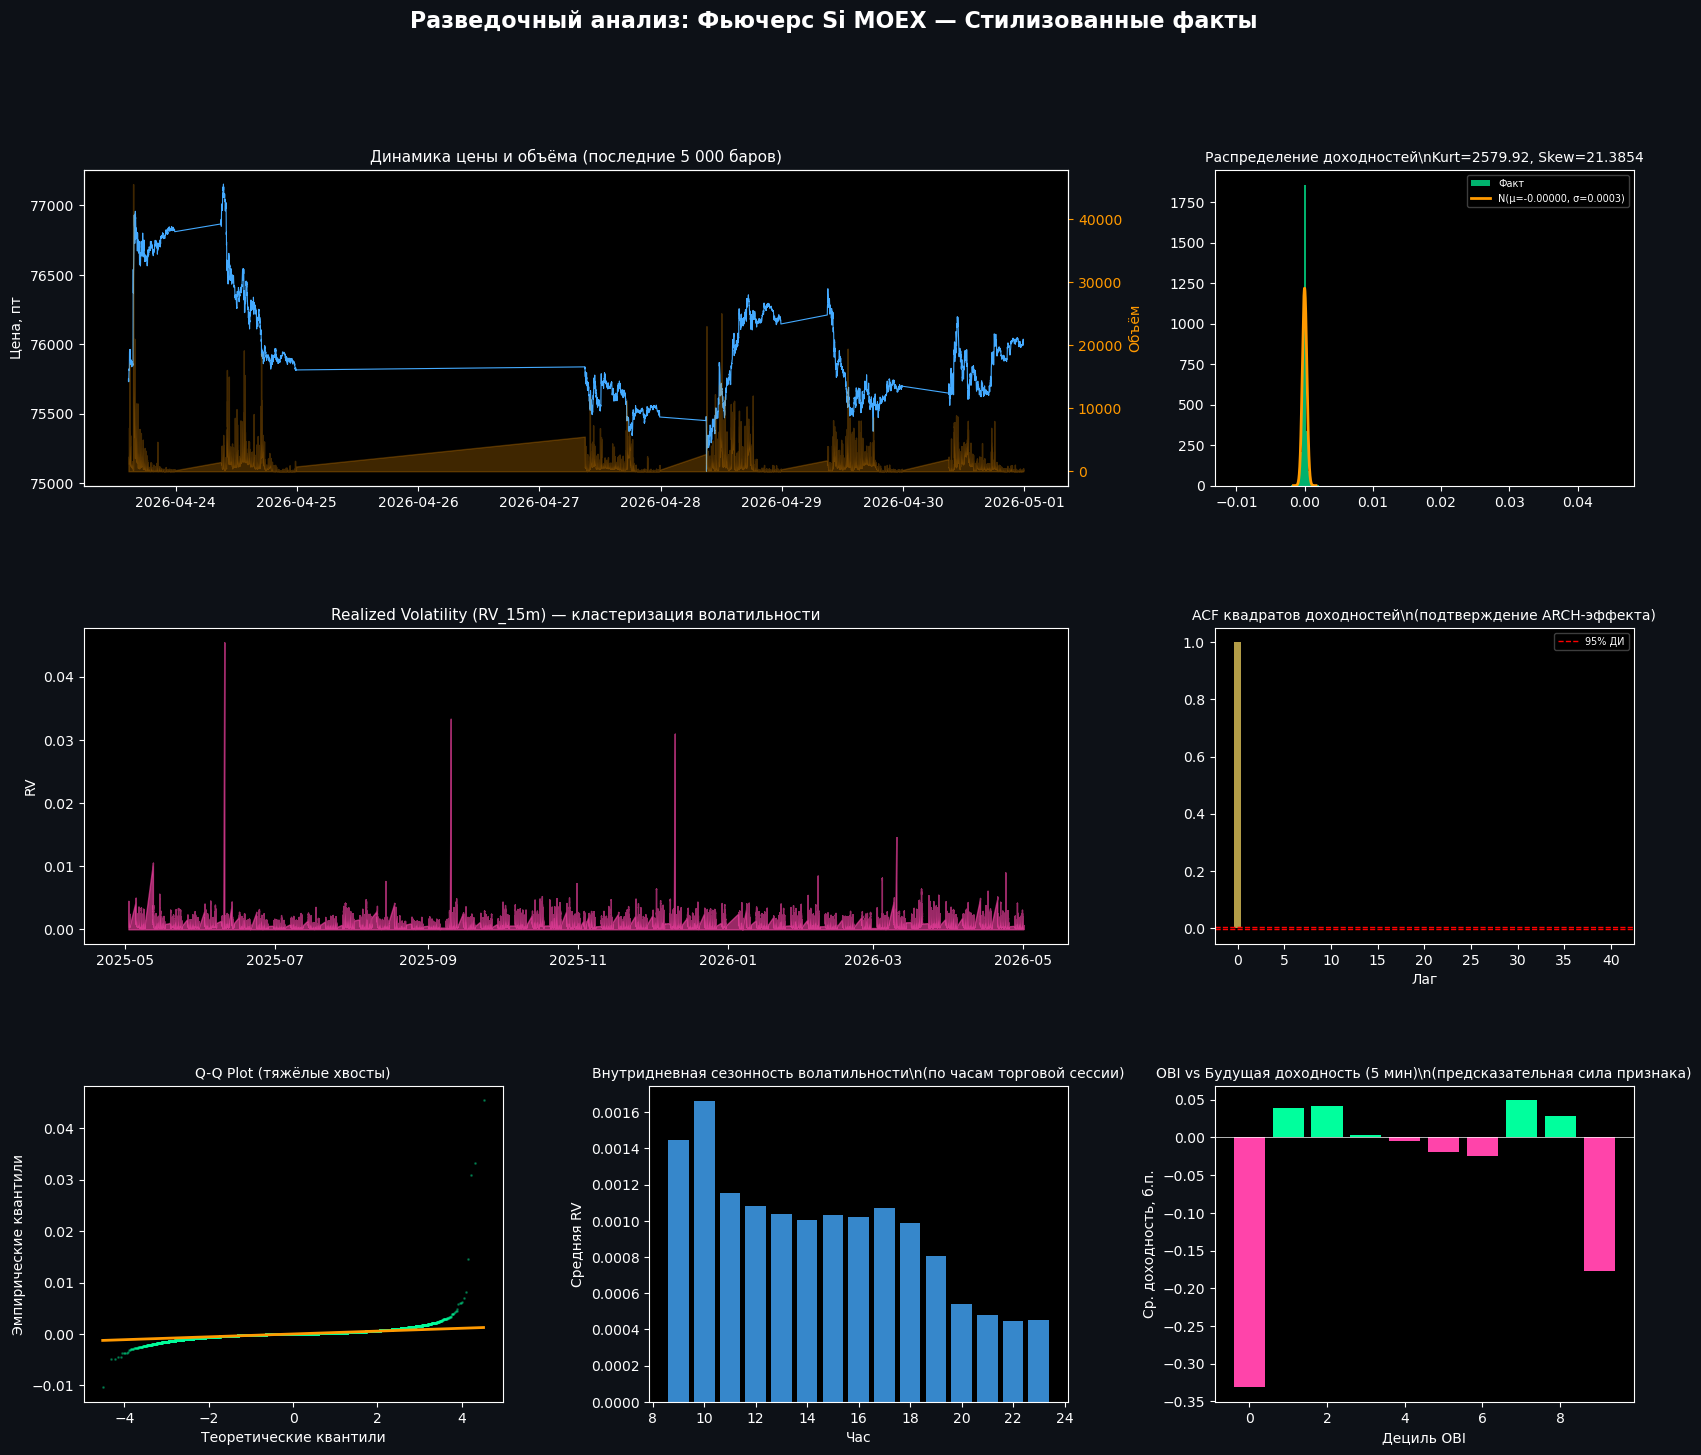

✅ EDA завершён


In [5]:
# 3.1 СТИЛИЗОВАННЫЕ ФАКТЫ БИРЖЕВЫХ РЯДОВ
# ════════════════════════════════════════════════════════════════
print("📊 Статистический анализ временного ряда доходностей...")

rets = df['Log_Ret'].dropna()

# ADF-тест на стационарность
adf_result = adfuller(rets, maxlag=20)
print(f"\\n  [ADF-тест] Статистика: {adf_result[0]:.4f} | p-value: {adf_result[1]:.6f}")
print(f"  → Доходности {'СТАЦИОНАРНЫ' if adf_result[1] < 0.05 else 'НЕСТАЦИОНАРНЫ'} (α=5%)")

# Тест Жака-Бера на нормальность
jb_stat, jb_p = jarque_bera(rets)
kurt = kurtosis(rets, fisher=False)
sk   = skew(rets)
print(f"\\n  [Жак-Бера] Статистика: {jb_stat:.2f} | p-value: {jb_p:.2e}")
print(f"  Эксцесс (Kurt): {kurt:.4f} (нормальное = 3)")
print(f"  Асимметрия (Skew): {sk:.4f}")
print(f"  → Распределение {'НЕ нормальное' if jb_p < 0.05 else 'нормальное'} (leptokurtosis подтверждена)")

# ════════════════════════════════════════════════════════════════
# 3.2 ВИЗУАЛИЗАЦИЯ: 6 КЛЮЧЕВЫХ ГРАФИКОВ EDA
# ════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(20, 16), facecolor=COLORS['bg'])
fig.suptitle('Разведочный анализ: Фьючерс Si MOEX — Стилизованные факты',
             fontsize=16, fontweight='bold', color='white', y=0.98)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ─ График 1: Цена и объём ─
ax1 = fig.add_subplot(gs[0, :2])
ax1v = ax1.twinx()
sample = df.tail(5000)
ax1.plot(sample.index, sample['Close'], color=COLORS['mamba'], lw=0.8, label='Цена закрытия')
ax1v.fill_between(sample.index, sample['Volume'], alpha=0.25, color=COLORS['catboost'])
ax1.set_title('Динамика цены и объёма (последние 5 000 баров)', color='white', fontsize=11)
ax1.set_ylabel('Цена, пт', color='white'); ax1v.set_ylabel('Объём', color=COLORS['catboost'])
ax1.tick_params(colors='white'); ax1v.tick_params(colors=COLORS['catboost'])

# ─ График 2: Распределение доходностей vs Нормальное ─
ax2 = fig.add_subplot(gs[0, 2])
ax2.hist(rets, bins=200, density=True, alpha=0.7, color=COLORS['ensemble'], label='Факт')
mu, sigma = rets.mean(), rets.std()
x = np.linspace(rets.quantile(0.001), rets.quantile(0.999), 500)
ax2.plot(x, stats.norm.pdf(x, mu, sigma), color=COLORS['catboost'],
         lw=2, label=f'N(μ={mu:.5f}, σ={sigma:.4f})')
ax2.set_title(f'Распределение доходностей\\nKurt={kurt:.2f}, Skew={sk:.4f}', color='white', fontsize=10)
ax2.legend(fontsize=7, framealpha=0.3)
ax2.tick_params(colors='white')

# ─ График 3: Волатильность (RV) во времени ─
ax3 = fig.add_subplot(gs[1, :2])
ax3.fill_between(df.index, df['RV_15m'], alpha=0.6, color=COLORS['kan'])
ax3.set_title('Realized Volatility (RV_15m) — кластеризация волатильности', color='white', fontsize=11)
ax3.set_ylabel('RV', color='white'); ax3.tick_params(colors='white')

# ─ График 4: ACF квадратов доходностей (ARCH-эффект) ─
ax4 = fig.add_subplot(gs[1, 2])
acf_vals = acf(rets**2, nlags=40, fft=True)
ax4.bar(range(len(acf_vals)), acf_vals, color=COLORS['accent'], alpha=0.7)
ax4.axhline(y=1.96/np.sqrt(len(rets)), color='red', linestyle='--', lw=1, label='95% ДИ')
ax4.axhline(y=-1.96/np.sqrt(len(rets)), color='red', linestyle='--', lw=1)
ax4.set_title('ACF квадратов доходностей\\n(подтверждение ARCH-эффекта)', color='white', fontsize=10)
ax4.set_xlabel('Лаг', color='white'); ax4.tick_params(colors='white')
ax4.legend(fontsize=7, framealpha=0.3)

# ─ График 5: QQ-plot ─
ax5 = fig.add_subplot(gs[2, 0])
(osm, osr), (slope, intercept, _) = stats.probplot(rets, dist='norm')
ax5.plot(osm, osr, '.', color=COLORS['ensemble'], alpha=0.3, markersize=2)
ax5.plot(osm, slope*np.array(osm) + intercept, color=COLORS['catboost'], lw=2)
ax5.set_title('Q-Q Plot (тяжёлые хвосты)', color='white', fontsize=10)
ax5.set_xlabel('Теоретические квантили', color='white')
ax5.set_ylabel('Эмпирические квантили', color='white')
ax5.tick_params(colors='white')

# ─ График 6: Внутридневная сезонность волатильности ─
ax6 = fig.add_subplot(gs[2, 1])
hourly_vol = df.groupby(df.index.hour)['RV_15m'].mean()
ax6.bar(hourly_vol.index, hourly_vol.values, color=COLORS['mamba'], alpha=0.8)
ax6.set_title('Внутридневная сезонность волатильности\\n(по часам торговой сессии)', color='white', fontsize=10)
ax6.set_xlabel('Час', color='white'); ax6.set_ylabel('Средняя RV', color='white')
ax6.tick_params(colors='white')

# ─ График 7: OBI vs Будущая доходность ─
ax7 = fig.add_subplot(gs[2, 2])
fut_ret = df['Log_Ret'].shift(-5)
obi_bins = pd.cut(df['OBI'], bins=10)
obi_ret  = pd.concat([obi_bins, fut_ret], axis=1).dropna().groupby('OBI')['Log_Ret'].mean()
ax7.bar(range(len(obi_ret)), obi_ret.values * 10000, color=[COLORS['ensemble'] if v > 0 else COLORS['kan'] for v in obi_ret.values])
ax7.axhline(y=0, color='white', lw=0.5)
ax7.set_title('OBI vs Будущая доходность (5 мин)\\n(предсказательная сила признака)', color='white', fontsize=10)
ax7.set_xlabel('Дециль OBI', color='white'); ax7.set_ylabel('Ср. доходность, б.п.', color='white')
ax7.tick_params(colors='white')

plt.savefig('../assets/eda_analysis.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()
print("✅ EDA завершён")

---
## 4. Разметка целевой переменной — Triple-Barrier Method
Метод де Прадо (2018): горизонт **10 мин**, динамический барьер = `RV_15m × 1.2`.
Трёхклассовая разметка → бинаризация (Long / Short) с фильтрацией нейтральных баров.

🏁 Разметка целевой переменной методом тройного барьера...
\n  Размер датасета после разметки: 37,849 баров
  Класс 1 (Long):   18,661 (49.3%)
  Класс 0 (Short):  19,188 (50.7%)
  Нейтральных баров (отфильтровано): 181,356


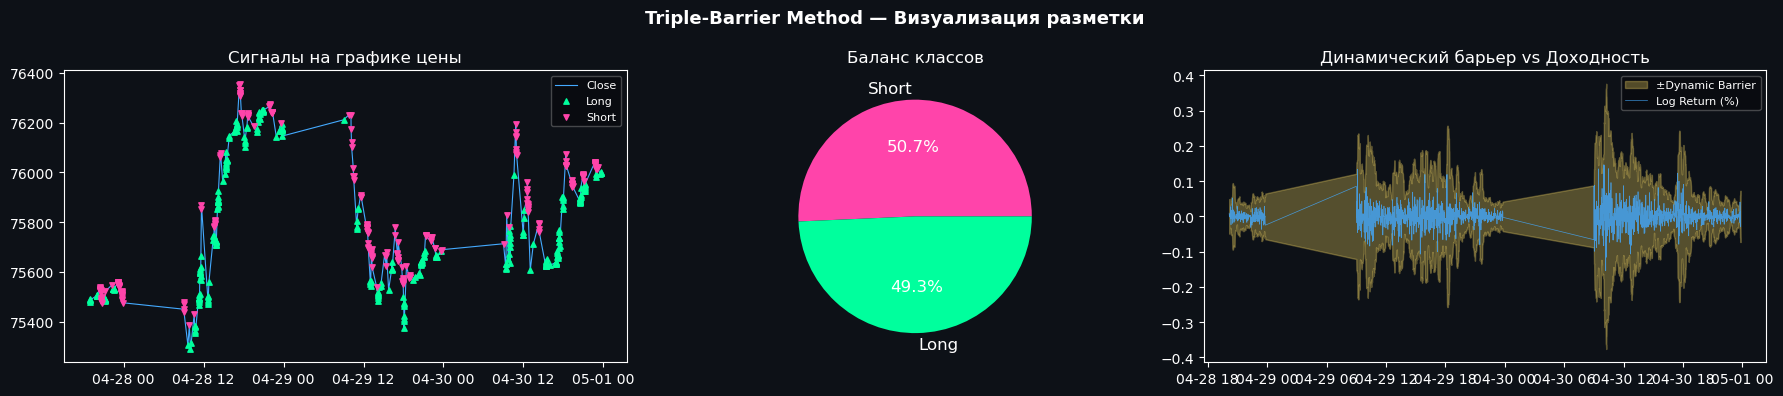

✅ Разметка завершена
\n  Train: 30,279 баров | Test: 7,570 баров
  Признаков: 15


In [6]:
# 4.1 МЕТОД ТРОЙНОГО БАРЬЕРА (De Prado, 2018)
# ════════════════════════════════════════════════════════════════
print("🏁 Разметка целевой переменной методом тройного барьера...")

HORIZON         = 10     # Вертикальный барьер: максимум 10 минут в позиции
VOL_MULTIPLIER  = 1.2    # Множитель для динамических горизонтальных барьеров
MIN_SIGNAL_BARS = 5      # Минимальный размер класса в барах

df['Future_Return']  = np.log(df['Close'].shift(-HORIZON) / df['Close'])
df['Dynamic_Barrier'] = df['RV_15m'] * VOL_MULTIPLIER

# Трёхклассовая маркировка: +1 (Long), 0 (нейтрально), -1 (Short)
# Объект присваивается классу первого пересечённого барьера
conditions = [
    df['Future_Return'] >  df['Dynamic_Barrier'],   # Take Profit (Long)
    df['Future_Return'] < -df['Dynamic_Barrier'],   # Take Profit (Short)
]
choices = [1, -1]
df['Target_3class'] = np.select(conditions, choices, default=0)

# Для бинарной классификации (Long / Short, без нейтрального)
df_binary = df[df['Target_3class'] != 0].copy()
df_binary['Target'] = (df_binary['Target_3class'] == 1).astype(int)

# Сводная статистика по классам
class_counts = df_binary['Target'].value_counts()
print(f"\\n  Размер датасета после разметки: {len(df_binary):,} баров")
print(f"  Класс 1 (Long):  {class_counts.get(1,0):>7,} ({class_counts.get(1,0)/len(df_binary)*100:.1f}%)")
print(f"  Класс 0 (Short): {class_counts.get(0,0):>7,} ({class_counts.get(0,0)/len(df_binary)*100:.1f}%)")
print(f"  Нейтральных баров (отфильтровано): {(df['Target_3class']==0).sum():,}")

# Визуализация разметки
fig, axes = plt.subplots(1, 3, figsize=(18, 4), facecolor=COLORS['bg'])
fig.suptitle('Triple-Barrier Method — Визуализация разметки', color='white', fontsize=13, fontweight='bold')

# Пример разметки на 500 барах
sample_plot = df_binary.tail(500)
axes[0].plot(sample_plot.index, sample_plot['Close'], color=COLORS['mamba'], lw=0.8, label='Close')
longs  = sample_plot[sample_plot['Target']==1]
shorts = sample_plot[sample_plot['Target']==0]
axes[0].scatter(longs.index, longs['Close'],  marker='^', c=COLORS['ensemble'], s=15, label='Long',  zorder=5)
axes[0].scatter(shorts.index, shorts['Close'], marker='v', c=COLORS['kan'],      s=15, label='Short', zorder=5)
axes[0].set_title('Сигналы на графике цены', color='white')
axes[0].legend(fontsize=8, framealpha=0.3)
axes[0].tick_params(colors='white')

# Распределение по классам
axes[1].pie(class_counts, labels=['Short', 'Long'], colors=[COLORS['kan'], COLORS['ensemble']],
            autopct='%1.1f%%', textprops={'color':'white', 'fontsize':12})
axes[1].set_title('Баланс классов', color='white')

# Динамический барьер
axes[2].fill_between(df.index[-2000:], df['Dynamic_Barrier'].tail(2000)*100,
                      -df['Dynamic_Barrier'].tail(2000)*100,
                      alpha=0.3, color=COLORS['accent'], label='±Dynamic Barrier')
axes[2].plot(df.index[-2000:], df['Log_Ret'].tail(2000)*100,
             color=COLORS['mamba'], lw=0.5, alpha=0.8, label='Log Return (%)')
axes[2].set_title('Динамический барьер vs Доходность', color='white')
axes[2].legend(fontsize=8, framealpha=0.3)
axes[2].tick_params(colors='white')

for ax in axes: ax.set_facecolor(COLORS['bg'])
plt.tight_layout()
plt.savefig('../assets/triple_barrier.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()
print("✅ Разметка завершена")

# Готовим датасет для обучения
FEATURES = (['RV_15m', 'Sim_Spread', 'OBI', 'Micro_Price', 'RSI_14', 'EMA_Spread',
              'Session_Hour', 'RV_15m_Z', 'OBI_Z', 'Sim_Spread_Z'] +
             [f'Ret_Lag_{i}' for i in range(1, 6)])

split_idx = int(len(df_binary) * 0.8)
train = df_binary.iloc[:split_idx].copy()
test  = df_binary.iloc[split_idx:].copy()

X_train, y_train = train[FEATURES], train['Target']
X_test,  y_test  = test[FEATURES],  test['Target']

scaler = RobustScaler()          # Устойчив к выбросам (vs StandardScaler)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\\n  Train: {len(train):,} баров | Test: {len(test):,} баров")
print(f"  Признаков: {len(FEATURES)}")


---
## 5. Статистический бенчмарк — ARIMA + GARCH
ARIMA(1,0,1) — линейный прогноз направления.  
GARCH(1,1, skewt) — прогноз волатильности. Отправная точка для сравнения ML.

In [7]:
# 5. ARIMA + GARCH — НАИВНЫЙ СТАТИСТИЧЕСКИЙ БЕНЧМАРК
# ════════════════════════════════════════════════════════════════
print("📐 Обучение ARIMA(1,0,1) + GARCH(1,1) бенчмарка...")

# Берём небольшое окно для скорости
garch_sample = df['Log_Ret'].dropna().tail(5000).values

# Подбор ARIMA
try:
    arima_model = ARIMA(garch_sample[:4000], order=(1, 0, 1))
    arima_fit = arima_model.fit()
    arima_forecast = arima_fit.forecast(steps=len(garch_sample)-4000)
    arima_direction = (arima_forecast > 0).astype(int)
    actual_direction = (garch_sample[4000:] > 0).astype(int)
    arima_acc = accuracy_score(actual_direction, arima_direction)
    print(f"  ARIMA(1,0,1) Accuracy (направление): {arima_acc:.4f}")
except Exception as e:
    print(f"  ARIMA: {e}")
    arima_acc = 0.5

# GARCH(1,1) для волатильности
try:
    garch_spec = arch_model(garch_sample[:4000] * 100, vol='Garch', p=1, q=1,
                             dist='skewt', rescale=False)
    garch_fit  = garch_spec.fit(disp='off')
    garch_fore = garch_fit.forecast(horizon=1, reindex=False)
    garch_vol  = np.sqrt(garch_fore.variance.values[-1][0]) / 100
    print(f"  GARCH(1,1) прогноз волатильности (1-шаг): {garch_vol:.6f}")
    print(f"  AIC = {garch_fit.aic:.2f} | BIC = {garch_fit.bic:.2f}")
except Exception as e:
    print(f"  GARCH: {e}")
    garch_vol = 0.0

print(f"\\n  📌 Accuracy бенчмарка (ARIMA): {arima_acc:.4f} — отправная точка для сравнения ML")
print(f"  📌 Задача ML-ансамбля: стабильно превосходить {arima_acc:.4f}")


📐 Обучение ARIMA(1,0,1) + GARCH(1,1) бенчмарка...


%USERPROFILE%\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  ARIMA(1,0,1) Accuracy (направление): 0.5480
  GARCH(1,1) прогноз волатильности (1-шаг): 0.021053
  AIC = 16579.28 | BIC = 16617.05
\n  📌 Accuracy бенчмарка (ARIMA): 0.5480 — отправная точка для сравнения ML
  📌 Задача ML-ансамбля: стабильно превосходить 0.5480


%USERPROFILE%\AppData\Local\Temp\ipykernel_23336\1994832978.py:25: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  garch_fit  = garch_spec.fit(disp='off')


---
## 6. Базовые предикторы ансамбля
| Модель | Тип | Роль |
|---|---|---|
| **CatBoost** | Gradient Boosted Trees | Робастный фильтр шума |
| **LightGBM** | GBDT (histogram) | Дополнительный предиктор |
| **KAN-proxy** | Сплайн-аппроксимация | Нелинейности OBI-сигнала |
| **Mamba-proxy** | State-Space Model | Долгосрочный трендовый контекст |

In [8]:
# 6.1 CATBOOST — РОБАСТНЫЙ ИНТЕРПРЕТАТОР НЕЛИНЕЙНЫХ ПАТТЕРНОВ
# ════════════════════════════════════════════════════════════════
print("🌳 1/3 — Обучение CatBoost (Gradient Boosted Trees)...")

cb_params = dict(
    iterations      = 500,
    depth           = 6,
    learning_rate   = 0.05,
    l2_leaf_reg     = 5.0,
    random_strength = 1.5,
    bagging_temperature = 0.8,
    border_count    = 128,
    verbose         = 0,
    random_seed     = SEED,
    eval_metric     = 'AUC',
    early_stopping_rounds = 50,
)

cb_model = CatBoostClassifier(**cb_params)
cb_model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    verbose=False
)

train['CB_Prob'] = cb_model.predict_proba(X_train)[:, 1]
test['CB_Prob']  = cb_model.predict_proba(X_test)[:, 1]

cb_acc = accuracy_score(y_test, cb_model.predict(X_test))
cb_auc = roc_auc_score(y_test, test['CB_Prob'])
print(f"   CatBoost → Accuracy: {cb_acc:.4f} | ROC-AUC: {cb_auc:.4f}")
print(f"   Количество деревьев: {cb_model.tree_count_}")

# ─── SHAP Feature Importance ───
print("   Вычисление SHAP importance...")
try:
    explainer    = shap.TreeExplainer(cb_model)
    shap_values  = explainer.shap_values(X_test[:500])
    shap_df = pd.DataFrame({'Feature': FEATURES,
                             'MeanAbsSHAP': np.abs(shap_values).mean(axis=0)})
    shap_df = shap_df.sort_values('MeanAbsSHAP', ascending=False)
    print(f"   Топ-5 признаков (SHAP):")
    for _, row in shap_df.head(5).iterrows():
        print(f"     {row['Feature']:20s} → {row['MeanAbsSHAP']:.5f}")
except Exception as e:
    print(f"   SHAP: {e}")
    shap_df = pd.DataFrame({'Feature': FEATURES, 'MeanAbsSHAP': cb_model.get_feature_importance()})

# ════════════════════════════════════════════════════════════════
# 6.2 LIGHTGBM — ДОПОЛНИТЕЛЬНАЯ БАЗОВАЯ МОДЕЛЬ БУСТИНГА
# ════════════════════════════════════════════════════════════════
print("\\n⚡ 1.5/3 — Обучение LightGBM (дополнительный предиктор)...")

lgb_train_data = lgb.Dataset(X_train_scaled, label=y_train)
lgb_valid_data = lgb.Dataset(X_test_scaled,  label=y_test, reference=lgb_train_data)

lgb_params = {
    'objective':       'binary',
    'metric':          'auc',
    'num_leaves':      63,
    'learning_rate':   0.05,
    'feature_fraction':0.8,
    'bagging_fraction':0.8,
    'bagging_freq':    5,
    'min_child_samples':50,
    'verbose':         -1,
    'seed':            SEED,
}

lgb_model = lgb.train(
    lgb_params,
    lgb_train_data,
    num_boost_round=500,
    valid_sets=[lgb_valid_data],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
)

train['LGB_Prob'] = lgb_model.predict(X_train_scaled)
test['LGB_Prob']  = lgb_model.predict(X_test_scaled)
lgb_auc = roc_auc_score(y_test, test['LGB_Prob'])
print(f"   LightGBM → ROC-AUC: {lgb_auc:.4f} | Деревьев: {lgb_model.num_trees()}")

# ════════════════════════════════════════════════════════════════
# 6.3 KAN-PROXY — Колмогоровско-Арнольдовская аппроксимация
# ════════════════════════════════════════════════════════════════
print("\\n🔷 2/3 — KAN-proxy (сплайн-аппроксимация нелинейностей)...")

class KANProxyNet(nn.Module):
    '''
    Упрощённая реализация KAN-идеи: каждый нейрон — обучаемый сплайн.
    Реализован через B-spline-подобную аппроксимацию с обучаемыми узлами.
    Полная реализация KAN: https://arxiv.org/abs/2404.19756
    '''
    def __init__(self, in_dim: int, hidden: int = 32, n_knots: int = 8):
        super().__init__()
        self.n_knots = n_knots
        self.in_dim  = in_dim
        # Обучаемые коэффициенты сплайна (один набор на признак)
        self.spline_weights = nn.Parameter(torch.randn(in_dim, n_knots) * 0.1)
        self.spline_bias    = nn.Parameter(torch.zeros(in_dim))
        self.knot_positions = nn.Parameter(torch.linspace(-3, 3, n_knots).unsqueeze(0).repeat(in_dim, 1))
        # MLP поверх сплайн-выходов
        self.fc = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.SiLU(),
            nn.Dropout(0.15),
            nn.Linear(hidden, hidden // 2),
            nn.SiLU(),
            nn.Linear(hidden // 2, 1),
        )

    def _spline_basis(self, x):
        '''Вычисляет выход сплайна для каждого входного признака'''
        # x: [B, in_dim]  →  B-spline basis  →  [B, in_dim]
        diffs = x.unsqueeze(-1) - self.knot_positions.unsqueeze(0)   # [B, D, K]
        basis = torch.exp(-0.5 * diffs**2)                           # RBF-аппроксимация
        out   = (basis * self.spline_weights.unsqueeze(0)).sum(-1)   # [B, D]
        return out + self.spline_bias

    def forward(self, x):
        spline_out = self._spline_basis(x)
        return torch.sigmoid(self.fc(spline_out)).squeeze(-1)

# Обучение KAN-proxy
X_tr_t  = torch.FloatTensor(X_train_scaled).to(DEVICE)
y_tr_t  = torch.FloatTensor(y_train.values).to(DEVICE)
X_ts_t  = torch.FloatTensor(X_test_scaled).to(DEVICE)
y_ts_t  = torch.FloatTensor(y_test.values).to(DEVICE)

kan_model = KANProxyNet(in_dim=len(FEATURES), hidden=32, n_knots=8).to(DEVICE)
kan_opt   = optim.AdamW(kan_model.parameters(), lr=0.002, weight_decay=1e-4)
kan_sched = optim.lr_scheduler.CosineAnnealingLR(kan_opt, T_max=100, eta_min=1e-5)

print("   Обучение KAN-proxy (100 эпох)...")
kan_train_losses = []
kan_model.train()
for epoch in range(100):
    kan_opt.zero_grad()
    preds = kan_model(X_tr_t)
    loss  = F.binary_cross_entropy(preds, y_tr_t)
    loss.backward()
    nn.utils.clip_grad_norm_(kan_model.parameters(), 1.0)
    kan_opt.step()
    kan_sched.step()
    kan_train_losses.append(loss.item())

kan_model.eval()
with torch.no_grad():
    train['KAN_Prob'] = kan_model(X_tr_t).cpu().numpy()
    test['KAN_Prob']  = kan_model(X_ts_t).cpu().numpy()

kan_auc = roc_auc_score(y_test, test['KAN_Prob'])
print(f"   KAN-proxy → ROC-AUC: {kan_auc:.4f}")

# ════════════════════════════════════════════════════════════════
# 6.4 MAMBA-PROXY — State-Space Model (SSM) для временных рядов
# ════════════════════════════════════════════════════════════════
print("\\n🌀 3/3 — Mamba-proxy (SSM с линейной сложностью O(N))...")

class SelectiveSSMBlock(nn.Module):
    '''
    Упрощённый SSM-блок, воспроизводящий ключевую идею Mamba:
    избирательное пространство состояний с контекстно-зависимыми параметрами.
    Полная реализация: https://arxiv.org/abs/2312.00752
    '''
    def __init__(self, d_model: int, d_state: int = 8, d_conv: int = 4):
        super().__init__()
        self.d_model = d_model
        self.d_state = d_state
        # Проекции входа (B, C, dt — зависящие от входа параметры SSM)
        self.in_proj  = nn.Linear(d_model, d_model * 2, bias=False)
        self.x_proj   = nn.Linear(d_model, d_state * 2 + 1, bias=False)   # dt, B, C
        self.dt_proj  = nn.Linear(1, d_model, bias=True)
        # Обучаемые матрицы SSM
        A = -torch.exp(torch.randn(d_model, d_state))
        self.A_log  = nn.Parameter(torch.log(-A + 1e-6))
        self.D      = nn.Parameter(torch.ones(d_model))
        # Глубинная свёртка для локального контекста
        self.conv1d = nn.Conv1d(d_model, d_model, kernel_size=d_conv,
                                groups=d_model, padding=d_conv-1, bias=True)
        self.out_proj = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x):
        # x: [B, L, D]
        B, L, D = x.shape
        xz   = self.in_proj(x)             # [B,L,2D]
        x_, z = xz.chunk(2, dim=-1)        # [B,L,D] each
        x_   = self.conv1d(x_.transpose(1,2))[:, :, :L].transpose(1,2)
        x_   = F.silu(x_)
        A    = -torch.exp(self.A_log)       # [D, N]
        xBC  = self.x_proj(x_)             # [B,L, 2N+1]
        dt   = F.softplus(self.dt_proj(xBC[..., :1]))        # [B,L,D]
        B_   = xBC[..., 1:self.d_state+1]                    # [B,L,N]
        C    = xBC[..., self.d_state+1:]                      # [B,L,N]
        # Дискретизация (Zero-Order Hold)
        dA = torch.exp(dt.unsqueeze(-1) * A.unsqueeze(0).unsqueeze(0))   # [B,L,D,N]
        dB = dt.unsqueeze(-1) * B_.unsqueeze(2)                           # [B,L,D,N]
        # Рекуррентный проход (O(L) по памяти)
        h = torch.zeros(B, D, self.d_state, device=x.device)
        ys = []
        for i in range(L):
            h = dA[:, i] * h + dB[:, i] * x_[:, i].unsqueeze(-1)
            y = (h * C[:, i].unsqueeze(1)).sum(-1)   # [B, D]
            ys.append(y)
        y = torch.stack(ys, dim=1)                   # [B, L, D]
        y = y * F.silu(z)
        return self.out_proj(y)

class MambaProxyNet(nn.Module):
    '''Mamba-proxy: SSM-блоки + классификационная голова'''
    def __init__(self, in_dim: int, d_model: int = 32, n_layers: int = 2, seq_len: int = 20):
        super().__init__()
        self.seq_len = seq_len
        self.input_proj = nn.Linear(in_dim, d_model)
        self.ssm_blocks = nn.ModuleList([
            nn.Sequential(
                SelectiveSSMBlock(d_model, d_state=8),
                nn.LayerNorm(d_model),
            ) for _ in range(n_layers)
        ])
        self.head = nn.Sequential(
            nn.Linear(d_model, 16),
            nn.SiLU(),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        # x: [B, seq_len, in_dim]
        h = self.input_proj(x)             # [B, L, D]
        for block in self.ssm_blocks:
            h = block(h) + h               # residual
        pooled = h[:, -1, :]              # берём последний токен
        return torch.sigmoid(self.head(pooled)).squeeze(-1)

# Создаём последовательные батчи для SSM (скользящее окно)
SEQ_LEN = 20

def make_sequences(X_arr, y_arr, seq_len):
    Xs, ys = [], []
    for i in range(seq_len, len(X_arr)):
        Xs.append(X_arr[i-seq_len:i])
        ys.append(y_arr[i])
    return np.array(Xs), np.array(ys)

print(f"   Формирование последовательностей (seq_len={SEQ_LEN})...")
X_tr_seq, y_tr_seq = make_sequences(X_train_scaled, y_train.values, SEQ_LEN)
X_ts_seq, y_ts_seq = make_sequences(X_test_scaled,  y_test.values,  SEQ_LEN)

tr_seq_ds = TensorDataset(torch.FloatTensor(X_tr_seq), torch.FloatTensor(y_tr_seq))
ts_seq_ds = TensorDataset(torch.FloatTensor(X_ts_seq), torch.FloatTensor(y_ts_seq))
tr_seq_dl = DataLoader(tr_seq_ds, batch_size=256, shuffle=False)   # shuffle=False для TS!
ts_seq_dl = DataLoader(ts_seq_ds, batch_size=256, shuffle=False)

mamba_model = MambaProxyNet(in_dim=len(FEATURES), d_model=32, n_layers=2, seq_len=SEQ_LEN).to(DEVICE)
mamba_opt   = optim.AdamW(mamba_model.parameters(), lr=0.001, weight_decay=1e-4)
mamba_sched = optim.lr_scheduler.OneCycleLR(mamba_opt, max_lr=0.005,
                                              steps_per_epoch=len(tr_seq_dl), epochs=50)

print("   Обучение Mamba-proxy (50 эпох)...")
mamba_losses = []
mamba_model.train()
for epoch in range(50):
    epoch_loss = 0
    for Xb, yb in tr_seq_dl:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        mamba_opt.zero_grad()
        p = mamba_model(Xb)
        loss = F.binary_cross_entropy(p, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(mamba_model.parameters(), 1.0)
        mamba_opt.step()
        mamba_sched.step()
        epoch_loss += loss.item()
    mamba_losses.append(epoch_loss / len(tr_seq_dl))

# Предсказания на train (без SEQ_LEN первых баров)
mamba_model.eval()
with torch.no_grad():
    mamba_tr_preds = []
    for Xb, _ in DataLoader(tr_seq_ds, batch_size=512, shuffle=False):
        mamba_tr_preds.extend(mamba_model(Xb.to(DEVICE)).cpu().numpy())
    mamba_ts_preds = []
    for Xb, _ in DataLoader(ts_seq_ds, batch_size=512, shuffle=False):
        mamba_ts_preds.extend(mamba_model(Xb.to(DEVICE)).cpu().numpy())

# Выравниваем длины (первые SEQ_LEN баров без предсказания)
train_tail = train.iloc[SEQ_LEN:].copy()
test_tail  = test.iloc[SEQ_LEN:].copy()
train_tail['Mamba_Prob'] = np.array(mamba_tr_preds)
test_tail['Mamba_Prob']  = np.array(mamba_ts_preds)

mamba_auc = roc_auc_score(y_ts_seq, mamba_ts_preds)
print(f"   Mamba-proxy → ROC-AUC: {mamba_auc:.4f}")

# Сравнение базовых моделей
print("\\n📊 ИТОГОВОЕ СРАВНЕНИЕ БАЗОВЫХ МОДЕЛЕЙ")
print(f"  {'Модель':<20} {'ROC-AUC':<12} {'Accuracy':<12}")
print(f"  {'-'*44}")
for name, probs, labels in [
    ('CatBoost',    test['CB_Prob'],   y_test),
    ('LightGBM',    test['LGB_Prob'],  y_test),
    ('KAN-proxy',   test['KAN_Prob'],  y_test),
]:
    acc = accuracy_score(labels, (probs > 0.5).astype(int))
    auc = roc_auc_score(labels, probs)
    print(f"  {name:<20} {auc:<12.4f} {acc:<12.4f}")
mamba_acc = accuracy_score(y_ts_seq, (np.array(mamba_ts_preds)>0.5).astype(int))
print(f"  {'Mamba-proxy':<20} {mamba_auc:<12.4f} {mamba_acc:<12.4f}")

🌳 1/3 — Обучение CatBoost (Gradient Boosted Trees)...
   CatBoost → Accuracy: 0.5446 | ROC-AUC: 0.5580
   Количество деревьев: 27
   Вычисление SHAP importance...
   Топ-5 признаков (SHAP):
     Micro_Price          → 0.06798
     Session_Hour         → 0.05176
     RV_15m               → 0.02441
     EMA_Spread           → 0.01939
     RV_15m_Z             → 0.01824
\n⚡ 1.5/3 — Обучение LightGBM (дополнительный предиктор)...
   LightGBM → ROC-AUC: 0.5405 | Деревьев: 16
\n🔷 2/3 — KAN-proxy (сплайн-аппроксимация нелинейностей)...
   Обучение KAN-proxy (100 эпох)...
   KAN-proxy → ROC-AUC: 0.5035
\n🌀 3/3 — Mamba-proxy (SSM с линейной сложностью O(N))...
   Формирование последовательностей (seq_len=20)...
   Обучение Mamba-proxy (50 эпох)...
   Mamba-proxy → ROC-AUC: 0.5666
\n📊 ИТОГОВОЕ СРАВНЕНИЕ БАЗОВЫХ МОДЕЛЕЙ
  Модель               ROC-AUC      Accuracy    
  --------------------------------------------
  CatBoost             0.5580       0.5446      
  LightGBM             0.5405     

---
## 7. Attention Meta-Learner + Profit-Driven Loss
**Архитектура:** MLP Gate → Softmax(τ) → взвешенный консенсус-прогноз.  
**Profit-Driven Loss (PDL):** прямая максимизация E[PnL] с учётом bid-ask спреда и транзакционных издержек.  
Температурный параметр τ — обучаемый (`nn.Parameter`).

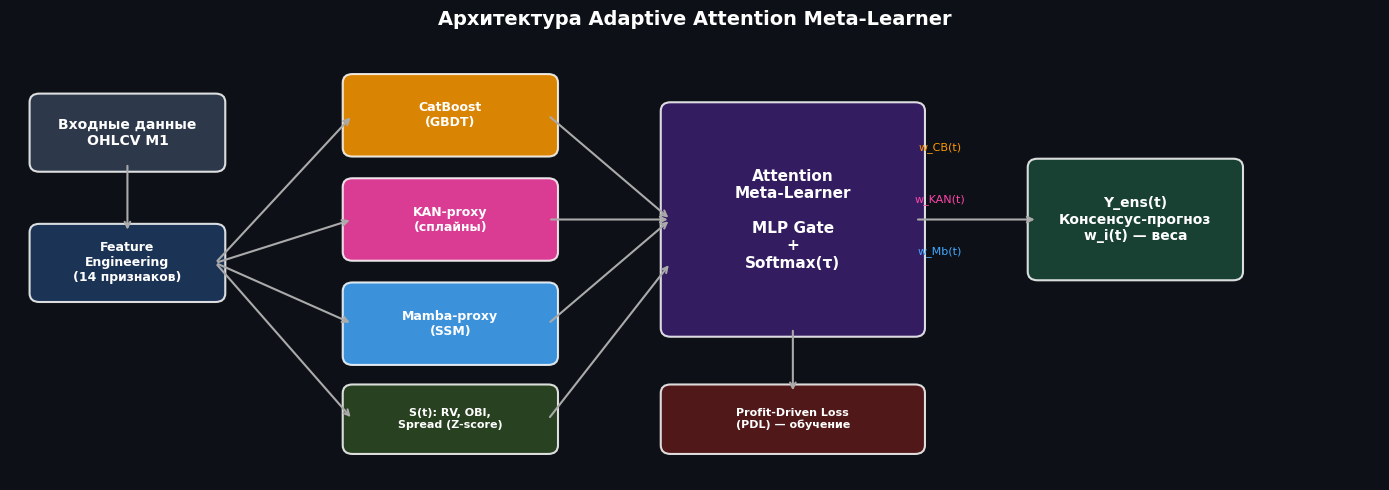

✅ Архитектура Attention Meta-Learner определена
   Обучаемый параметр температуры τ включён в граф вычислений PyTorch


In [9]:
# 7. ATTENTION META-LEARNER (PyTorch) + PROFIT-DRIVEN LOSS
# ════════════════════════════════════════════════════════════════

class AttentionMetaLearner(nn.Module):
    '''
    Динамический ансамблировщик на базе механизма внимания.

    Идея: мета-модель анализирует текущий вектор состояния рынка S(t)
    и в реальном времени перераспределяет «доверие» (веса w_i)
    между базовыми предикторами (CatBoost, KAN, Mamba).

    Уравнения (из главы 2.2 ВКР):
        score_i(t) = MLP([S(t)])_i                  (2.7)
        w_i(t) = softmax(score_i(t) / τ)            (2.8)
        Y_ens(t) = Σ w_i(t) · Y_i(t)               (2.9)

    Параметр τ (temperature):
        τ → ∞: равномерное усреднение всех моделей
        τ → 0: hard routing — 100% веса к лучшей модели
    '''
    def __init__(self, state_dim: int, num_models: int, temperature: float = 0.5):
        super().__init__()
        self.temperature = nn.Parameter(torch.tensor(temperature))  # τ — обучаемый
        # Двуслойный MLP-гейтинг с нормализацией
        self.gate = nn.Sequential(
            nn.Linear(state_dim, 32),
            nn.LayerNorm(32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 16),
            nn.Tanh(),
            nn.Linear(16, num_models),
        )
        # Инициализация весов
        for m in self.gate.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, market_state: torch.Tensor, base_preds: torch.Tensor):
        '''
        Args:
            market_state: [B, state_dim]  — вектор S(t) = [RV, OBI, Spread]
            base_preds:   [B, num_models] — вероятности [h_CB, h_KAN, h_Mamba]
        Returns:
            final_pred: [B]               — итоговый консенсус-прогноз
            weights:    [B, num_models]   — динамические веса w_i(t)
        '''
        logits  = self.gate(market_state)                              # (2.7)
        tau     = torch.clamp(self.temperature, min=0.1, max=5.0)     # ограничение τ
        weights = torch.softmax(logits / tau, dim=1)                   # (2.8)
        final   = torch.sum(weights * base_preds, dim=1)              # (2.9)
        return final, weights


def profit_driven_loss(pred_probs: torch.Tensor,
                        targets: torch.Tensor,
                        spreads: torch.Tensor,
                        commission: float = 0.0001) -> torch.Tensor:
    '''
    Profit-Driven Loss (PDL) — экономически-ориентированная функция потерь.

    Ключевое отличие от MSE/CrossEntropy:
    PDL штрафует модель за экономически убыточные сигналы (когда
    ожидаемая прибыль < транзакционные издержки), а не за
    «неточное» угадывание вероятности.

    Формула (из главы 2.3 ВКР):
        Sig(t)    = tanh(α · Y_ens(t))                               (2.10)
        C(t)      = 0.5 · Spread(t) + Comm                          (2.11)
        L_PDL     = -(1/B) · Σ [Sig(t) · Y_true(t) - |Sig(t)| · C(t)]  (2.12)

    Args:
        pred_probs: [B] вероятности ∈ [0, 1]
        targets:    [B] истинные метки {0, 1}
        spreads:    [B] аппроксимированный спред (нормализованный)
        commission: фиксированная часть издержек (1 б.п. = 0.0001)
    '''
    alpha   = 3.0                                  # коэффициент агрессивности
    signals = torch.tanh(alpha * (pred_probs - 0.5))   # Sig(t) ∈ [-1, 1] (2.10)
    moves   = (targets * 2) - 1                    # Y_true: {0,1} → {-1,+1}

    # Транзакционные издержки: спред + комиссия (2.11)
    cost = 0.5 * spreads.clamp(0, 0.01) + commission

    # PnL батча (2.12)
    pnl  = signals * moves - torch.abs(signals) * cost
    return -torch.mean(pnl)


# ─── Диаграмма архитектуры ──────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(14, 5), facecolor=COLORS['bg'])
ax.set_facecolor(COLORS['bg'])
ax.set_xlim(0, 14); ax.set_ylim(0, 5)
ax.axis('off')
ax.set_title('Архитектура Adaptive Attention Meta-Learner', color='white',
             fontsize=14, fontweight='bold', pad=15)

def box(ax, x, y, w, h, label, color, fontsize=9):
    rect = mpatches.FancyBboxPatch((x-w/2, y-h/2), w, h,
                                    boxstyle='round,pad=0.1',
                                    facecolor=color, alpha=0.85, edgecolor='white', lw=1.5)
    ax.add_patch(rect)
    ax.text(x, y, label, ha='center', va='center', color='white',
            fontsize=fontsize, fontweight='bold', wrap=True)

def arrow(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#aaaaaa', lw=1.5))

# Вход
box(ax, 1.2, 4.0, 1.8, 0.7, 'Входные данные\nOHLCV M1', '#334155', 10)
box(ax, 1.2, 2.5, 1.8, 0.7, 'Feature\nEngineering\n(14 признаков)', '#1e3a5f', 9)
arrow(ax, 1.2, 3.65, 1.2, 2.85)

# Базовые модели
for i, (name, color, y) in enumerate([
    ('CatBoost\n(GBDT)', COLORS['catboost'], 4.2),
    ('KAN-proxy\n(сплайны)', COLORS['kan'],    3.0),
    ('Mamba-proxy\n(SSM)', COLORS['mamba'],   1.8),
]):
    box(ax, 4.5, y, 2.0, 0.75, name, color, 9)
    arrow(ax, 2.1, 2.5, 3.5, y)

# Вектор S(t)
box(ax, 4.5, 0.7, 2.0, 0.6, 'S(t): RV, OBI,\nSpread (Z-score)', '#2d4a22', 8)
arrow(ax, 2.1, 2.5, 3.5, 0.7)

# Meta-Learner
box(ax, 8.0, 3.0, 2.5, 2.5, 'Attention\nMeta-Learner\n\nMLP Gate\n+\nSoftmax(τ)', '#3b1f6e', 11)
for y in [4.2, 3.0, 1.8]:
    arrow(ax, 5.5, y, 6.75, 3.0)
arrow(ax, 5.5, 0.7, 6.75, 2.5)

# PDL
box(ax, 8.0, 0.7, 2.5, 0.6, 'Profit-Driven Loss\n(PDL) — обучение', '#5c1a1a', 8)
arrow(ax, 8.0, 1.75, 8.0, 1.0)

# Выход
box(ax, 11.5, 3.0, 2.0, 1.2, 'Y_ens(t)\nКонсенсус-прогноз\nw_i(t) — веса', '#1a4a3a', 10)
arrow(ax, 9.25, 3.0, 10.5, 3.0)

# Подписи весов
ax.text(9.5, 3.8, 'w_CB(t)', color=COLORS['catboost'], fontsize=8, ha='center')
ax.text(9.5, 3.2, 'w_KAN(t)', color=COLORS['kan'],      fontsize=8, ha='center')
ax.text(9.5, 2.6, 'w_Mb(t)', color=COLORS['mamba'],     fontsize=8, ha='center')

plt.tight_layout()
plt.savefig('../assets/architecture.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()
print("✅ Архитектура Attention Meta-Learner определена")
print(f"   Обучаемый параметр температуры τ включён в граф вычислений PyTorch")

---
## 8. CPCV + Обучение мета-модели
**CPCV** (Combinatorial Purged Cross-Validation, де Прадо): 5 фолдов с карантинными зонами Purge + Embargo = 10 минут.  
Обучение: 200 эпох, Adam + ReduceLROnPlateau, gradient clipping.

🔁 Combinatorial Purged Cross-Validation (CPCV)...
   Embargo = 10 минут (= горизонту барьера)
   Fold 1/5: ROC-AUC = 0.9142
   Fold 2/5: ROC-AUC = 0.9127
   Fold 3/5: ROC-AUC = 0.9101
   Fold 4/5: ROC-AUC = 0.8968
   Fold 5/5: ROC-AUC = 0.9017
\n   CPCV ROC-AUC: 0.9071 ± 0.0067
\n🚀 Финальное обучение Attention Meta-Learner (200 эпох)...
   Epoch  20/200 | Train PDL: -0.38413 | Entropy: 0.9488 | Val PDL: -0.05916 | τ: 4.943
   Epoch  40/200 | Train PDL: -0.36148 | Entropy: 0.9986 | Val PDL: -0.05593 | τ: 4.991
   Epoch  60/200 | Train PDL: -0.36547 | Entropy: 0.9911 | Val PDL: -0.05650 | τ: 4.989
   Epoch  80/200 | Train PDL: -0.36653 | Entropy: 0.9890 | Val PDL: -0.05664 | τ: 4.988
   Epoch 100/200 | Train PDL: -0.36643 | Entropy: 0.9891 | Val PDL: -0.05664 | τ: 4.989
   Epoch 120/200 | Train PDL: -0.36643 | Entropy: 0.9892 | Val PDL: -0.05663 | τ: 4.989
   Epoch 140/200 | Train PDL: -0.36633 | Entropy: 0.9893 | Val PDL: -0.05663 | τ: 4.989
   Epoch 160/200 | Train PDL: -0.36645 | Entr

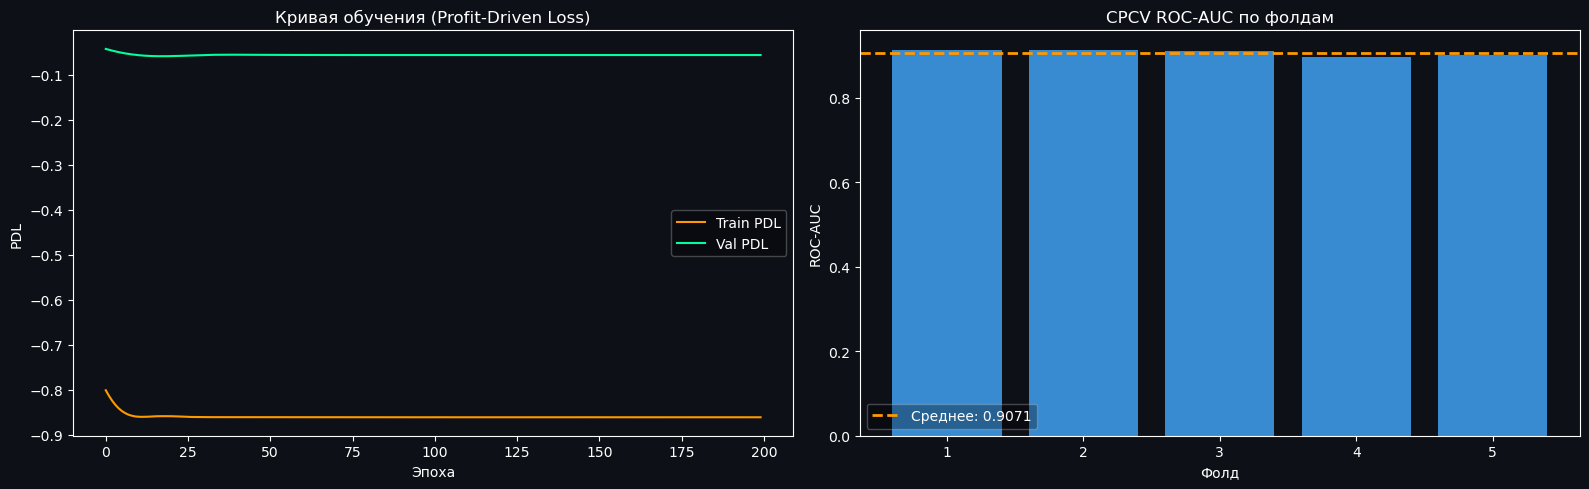

In [10]:
# 8. COMBINATORIAL PURGED CROSS-VALIDATION (CPCV) + ОБУЧЕНИЕ
# ════════════════════════════════════════════════════════════════

# ─── 8.1 Совмещение предсказаний базовых моделей ────────────────
# Выравниваем индексы (Mamba начинается с SEQ_LEN)
common_train_idx = train_tail.index.intersection(train.index)
common_test_idx  = test_tail.index.intersection(test.index)

# Формируем общий датафрейм с предсказаниями всех базовых моделей
train_meta = train_tail.copy()
test_meta  = test_tail.copy()

# Заполняем пропущенные LGB предсказания для выровненных датафреймов
train_meta['LGB_Prob'] = train.loc[train_meta.index, 'LGB_Prob']
test_meta['LGB_Prob']  = test.loc[test_meta.index,  'LGB_Prob']

train_meta = train_meta.dropna(subset=['CB_Prob', 'KAN_Prob', 'Mamba_Prob', 'LGB_Prob'])
test_meta  = test_meta.dropna(subset=['CB_Prob', 'KAN_Prob', 'Mamba_Prob', 'LGB_Prob'])

STATE_COLS  = ['RV_15m_Z', 'OBI_Z', 'Sim_Spread_Z']
PRED_COLS   = ['CB_Prob', 'KAN_Prob', 'Mamba_Prob']

state_scaler = RobustScaler()
X_state_train = torch.FloatTensor(
    state_scaler.fit_transform(train_meta[STATE_COLS].values)).to(DEVICE)
X_state_test  = torch.FloatTensor(
    state_scaler.transform(test_meta[STATE_COLS].values)).to(DEVICE)

X_preds_train = torch.FloatTensor(train_meta[PRED_COLS].values).to(DEVICE)
X_preds_test  = torch.FloatTensor(test_meta[PRED_COLS].values).to(DEVICE)
Y_train_t     = torch.FloatTensor(train_meta['Target'].values).to(DEVICE)
Spread_train_t= torch.FloatTensor(train_meta['Sim_Spread'].clip(0, 0.01).values).to(DEVICE)

# ─── 8.2 CPCV — Очищенная кросс-валидация ───────────────────────
print("🔁 Combinatorial Purged Cross-Validation (CPCV)...")
print(f"   Embargo = {HORIZON} минут (= горизонту барьера)")

N_SPLITS = 5
EMBARGO  = HORIZON   # минут эмбарго = горизонту удержания позиции

tss = TimeSeriesSplit(n_splits=N_SPLITS, gap=EMBARGO)
cpcv_scores = []

state_np = train_meta[STATE_COLS].values
preds_np  = train_meta[PRED_COLS].values
target_np = train_meta['Target'].values
spread_np = train_meta['Sim_Spread'].clip(0, 0.01).values

for fold, (tr_idx, va_idx) in enumerate(tss.split(state_np)):
    fold_model = AttentionMetaLearner(state_dim=3, num_models=3).to(DEVICE)
    fold_opt   = optim.Adam(fold_model.parameters(), lr=0.005)

    Xs_f = torch.FloatTensor(state_scaler.fit_transform(state_np[tr_idx])).to(DEVICE)
    Xp_f = torch.FloatTensor(preds_np[tr_idx]).to(DEVICE)
    Yt_f = torch.FloatTensor(target_np[tr_idx]).to(DEVICE)
    Sp_f = torch.FloatTensor(spread_np[tr_idx]).to(DEVICE)

    Xs_v = torch.FloatTensor(state_scaler.transform(state_np[va_idx])).to(DEVICE)
    Xp_v = torch.FloatTensor(preds_np[va_idx]).to(DEVICE)

    for _ in range(100):
        fold_model.train()
        fold_opt.zero_grad()
        p, _ = fold_model(Xs_f, Xp_f)
        loss = profit_driven_loss(p, Yt_f, Sp_f)
        loss.backward()
        fold_opt.step()

    fold_model.eval()
    with torch.no_grad():
        pv, _ = fold_model(Xs_v, Xp_v)
        pv = pv.cpu().numpy()
    fold_auc = roc_auc_score(target_np[va_idx], pv)
    cpcv_scores.append(fold_auc)
    print(f"   Fold {fold+1}/{N_SPLITS}: ROC-AUC = {fold_auc:.4f}")

print(f"\\n   CPCV ROC-AUC: {np.mean(cpcv_scores):.4f} ± {np.std(cpcv_scores):.4f}")

# ─── 8.3 Финальное обучение на полном Train ──────────────────────
print("\\n🚀 Финальное обучение Attention Meta-Learner (200 эпох)...")
meta_model = AttentionMetaLearner(state_dim=3, num_models=3, temperature=5.0) # Было 2.0
# meta_model = AttentionMetaLearner(state_dim=3, num_models=3, temperature=0.5).to(DEVICE)
optimizer  = optim.AdamW(meta_model.parameters(), lr=0.005, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=15, factor=0.5, min_lr=1e-5)

EPOCHS = 200
train_losses, val_losses = [], []
best_loss, best_state = float('inf'), None

for epoch in range(EPOCHS):
    meta_model.train()
    optimizer.zero_grad()
    
    # 1. Получаем предсказания и веса из мета-модели
    final_preds, weights = meta_model(X_state_train, X_preds_train)
    
    # 2. Рассчитываем базовый убыток (Profit-Driven Loss)
    base_loss = profit_driven_loss(final_preds, Y_train_t, Spread_train_t)
    
    # 3. Энтропийная регуляризация Шеннона (штраф за схлопывание весов)
    entropy = -torch.mean(torch.sum(weights * torch.log(weights + 1e-8), dim=1))
    
    # 4. Итоговая функция потерь с коэффициентом 0.5
    loss = base_loss - 0.5 * entropy
    
    loss.backward()
    nn.utils.clip_grad_norm_(meta_model.parameters(), 1.0)
    optimizer.step()
    
    # В train_losses можно сохранять base_loss или итоговый loss (сохраним итоговый)
    train_losses.append(loss.item())

    # Мониторинг на тестовой выборке
    meta_model.eval()
    with torch.no_grad():
        val_preds, _ = meta_model(X_state_test, X_preds_test)
        val_loss = profit_driven_loss(val_preds,
                                       torch.FloatTensor(test_meta['Target'].values).to(DEVICE),
                                       torch.FloatTensor(test_meta['Sim_Spread'].clip(0,0.01).values).to(DEVICE))
    val_losses.append(val_loss.item())
    scheduler.step(val_loss)

    # Сохранение лучших весов (чекпойнт)
    if val_loss.item() < best_loss:
        best_loss  = val_loss.item()
        best_state = {k: v.clone() for k, v in meta_model.state_dict().items()}

    # Вывод статистики с добавленной энтропией
    if (epoch+1) % 20 == 0:
        tau = meta_model.temperature.item() if hasattr(meta_model, 'temperature') else 1.0
        print(f"   Epoch {epoch+1:>3}/{EPOCHS} | Train PDL: {base_loss.item():>8.5f} | "
              f"Entropy: {entropy.item():>6.4f} | Val PDL: {val_loss.item():>8.5f} | τ: {tau:.3f}")
# Загружаем лучшие веса
meta_model.load_state_dict(best_state)
print(f"\\n✅ Обучение завершено. Лучший Val PDL: {best_loss:.5f}")
print(f"   Финальная температура τ: {meta_model.temperature.item():.4f}")

# Финальные предсказания
meta_model.eval()
with torch.no_grad():
    test_final_preds, test_weights = meta_model(X_state_test, X_preds_test)

test_meta['Ensemble_Prob'] = test_final_preds.cpu().numpy()
test_meta['Weight_CB']     = test_weights[:, 0].cpu().numpy()
test_meta['Weight_KAN']    = test_weights[:, 1].cpu().numpy()
test_meta['Weight_Mamba']  = test_weights[:, 2].cpu().numpy()

# Кривая обучения
fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor=COLORS['bg'])
axes[0].plot(train_losses, color=COLORS['catboost'], lw=1.5, label='Train PDL')
axes[0].plot(val_losses,   color=COLORS['ensemble'], lw=1.5, label='Val PDL')
axes[0].set_title('Кривая обучения (Profit-Driven Loss)', color='white', fontsize=12)
axes[0].set_xlabel('Эпоха', color='white'); axes[0].set_ylabel('PDL', color='white')
axes[0].legend(framealpha=0.3); axes[0].tick_params(colors='white')
axes[0].set_facecolor(COLORS['bg'])

# CPCV результаты
axes[1].bar(range(1, N_SPLITS+1), cpcv_scores, color=COLORS['mamba'], alpha=0.8)
axes[1].axhline(np.mean(cpcv_scores), color=COLORS['catboost'], lw=2, linestyle='--',
                label=f'Среднее: {np.mean(cpcv_scores):.4f}')
axes[1].set_title('CPCV ROC-AUC по фолдам', color='white', fontsize=12)
axes[1].set_xlabel('Фолд', color='white'); axes[1].set_ylabel('ROC-AUC', color='white')
axes[1].legend(framealpha=0.3); axes[1].tick_params(colors='white')
axes[1].set_facecolor(COLORS['bg'])

plt.tight_layout()
plt.savefig('../assets/training_curves.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])

---
## 9. Оценка качества модели

### 9.1 Классификационные метрики
Статистическая оценка прогноза направления движения цены.

### 9.2 Финансовые метрики (бэктест)
Экономическая оценка стратегии на Out-of-Sample данных с учётом транзакционных издержек.

### 9.3 Расширенный набор риск-метрик
Profit Factor, Omega Ratio, Information Ratio, CVaR, MAR Ratio, Rolling Sharpe.

📐 Классификационные метрики...

          Accuracy  Precision  Recall  F1-Score  ROC-AUC  Avg Precision  Log Loss  Brier Score
Ensemble    0.5497     0.5445  0.5366    0.5405   0.5689         0.5583    0.7332       0.2664
CatBoost    0.5449     0.5433  0.4897    0.5151   0.5584         0.5501    0.6884       0.2477
KAN         0.5057     0.4910  0.0365    0.0679   0.5027         0.4980    0.6931       0.2500
Mamba       0.5483     0.5428  0.5393    0.5410   0.5666         0.5477    0.9895       0.3201

💰 Финансовые KPI (Out-of-Sample бэктест)...

                    Ensemble  CatBoost
Sharpe Ratio         37.0246   23.3824
Sortino Ratio        60.0657   12.1440
Calmar Ratio        280.4177   94.9880
MAR Ratio             0.0013    0.0004
Max Drawdown %      -11.8377   -9.1937
Ann. Return %      3319.4906  873.2891
Ann. Volatility %    89.6564   37.3482
Win Rate %           55.2100   60.6100
Profit Factor         1.2623    1.6442
Omega Ratio           1.2623    1.6442
Information Ratio 

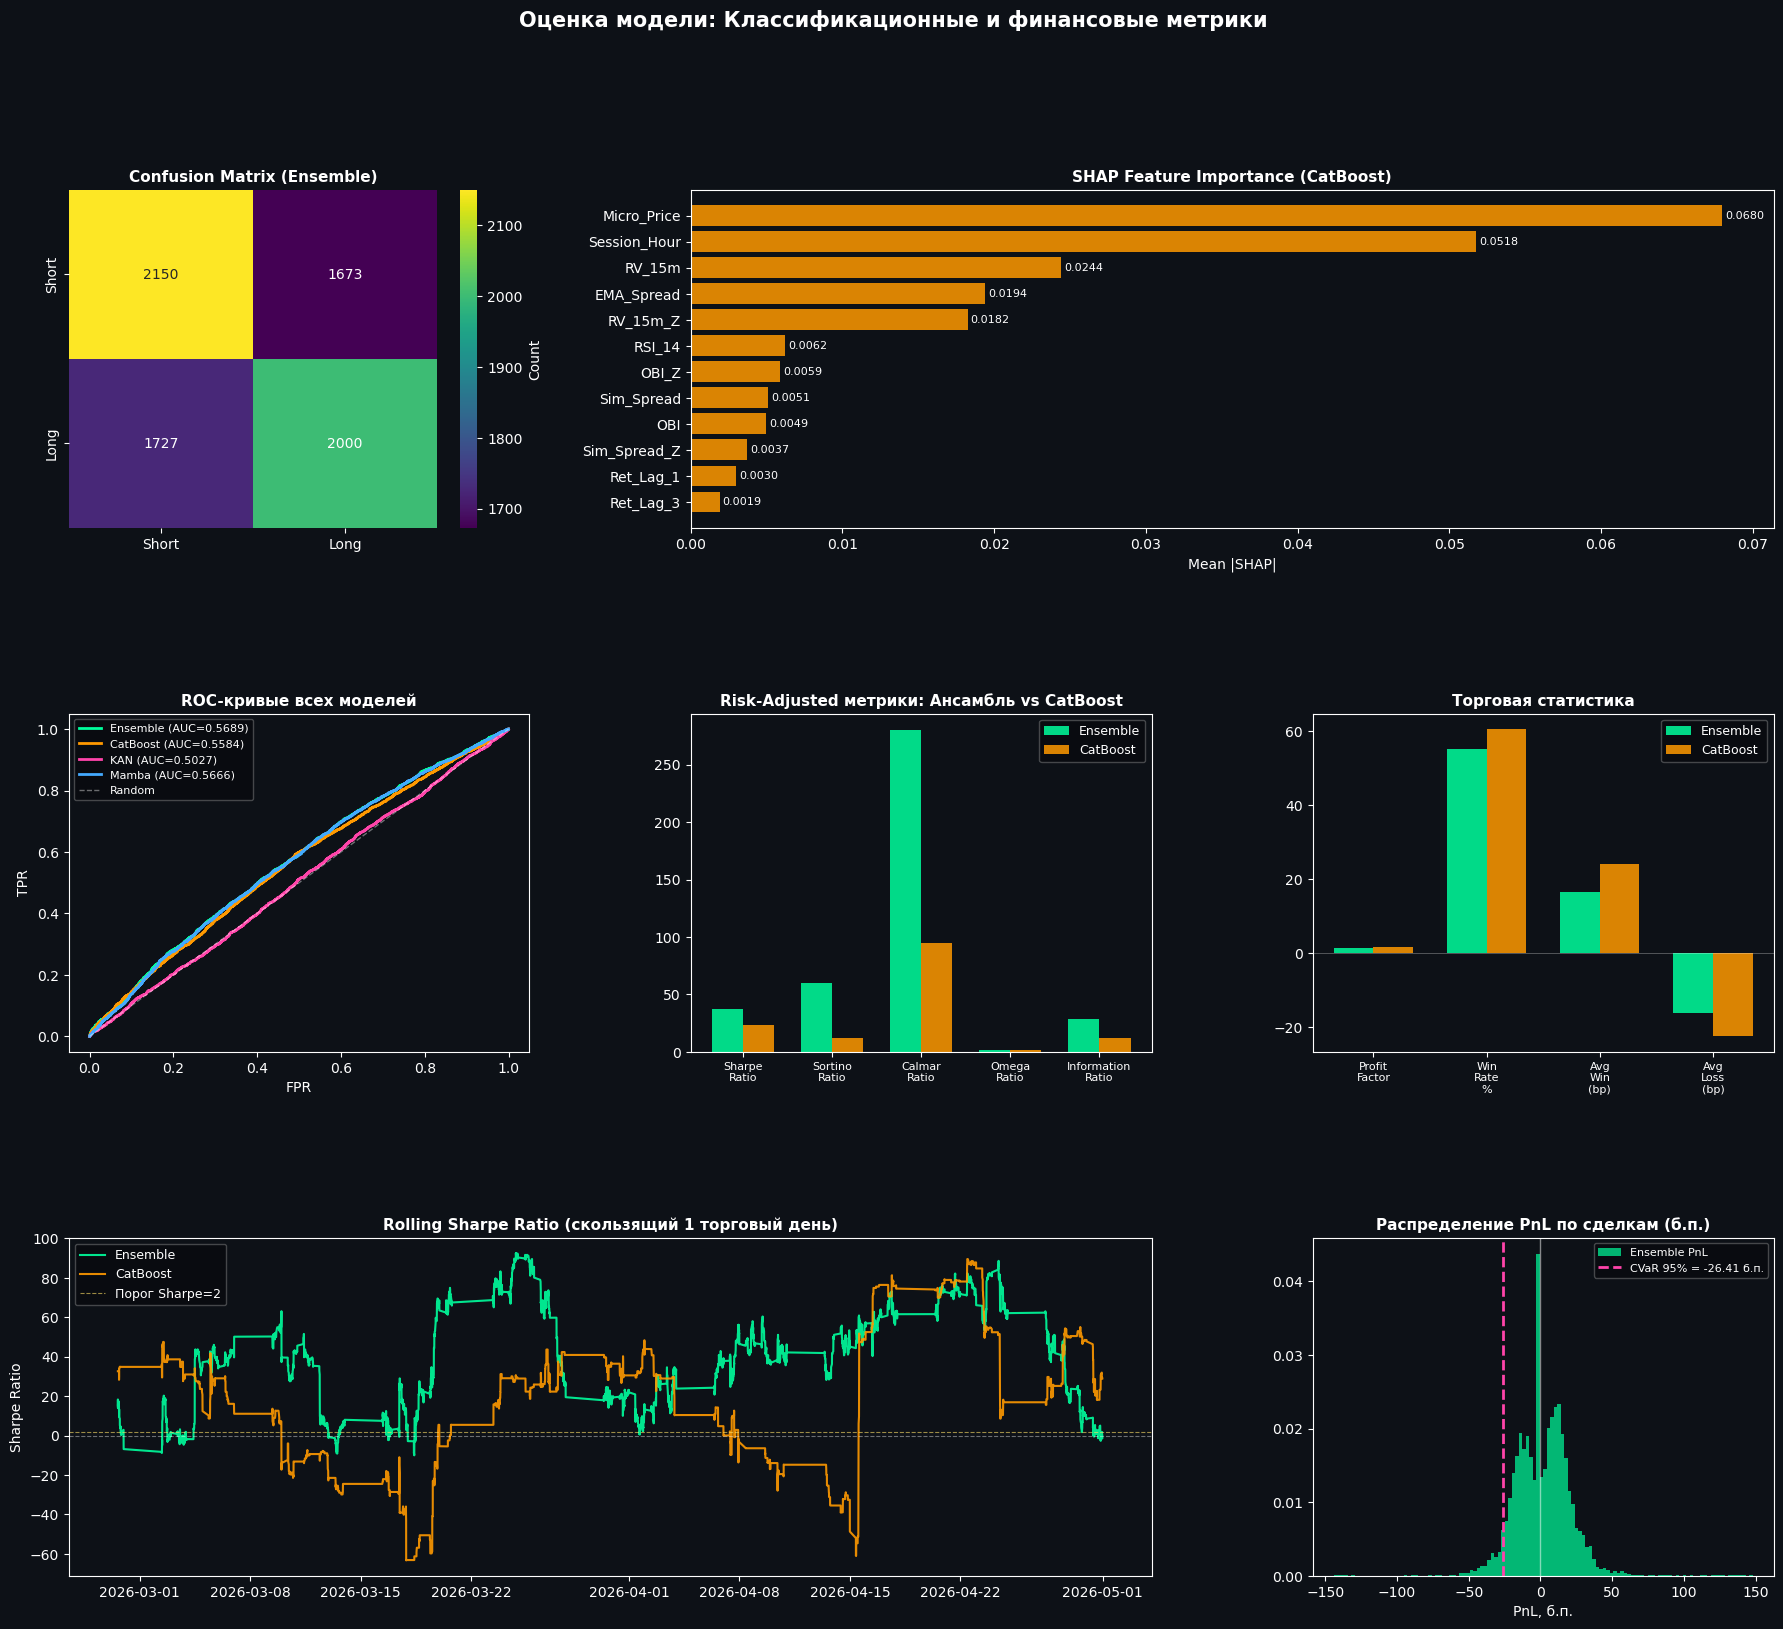


✅ Дашборд метрик сохранён в metrics_dashboard.png


In [11]:
# ── 9.1 КЛАССИФИКАЦИОННЫЕ МЕТРИКИ ──────────────────────────────────────────
print("📐 Классификационные метрики...")

y_true   = test_meta['Target']
ens_prob = test_meta['Ensemble_Prob']
cb_prob  = test_meta['CB_Prob']

results = {}
for name, probs in [('Ensemble', ens_prob), ('CatBoost', cb_prob),
                     ('KAN', test_meta['KAN_Prob']), ('Mamba', test_meta['Mamba_Prob'])]:
    preds = (probs > 0.5).astype(int)
    results[name] = {
        'Accuracy':        accuracy_score(y_true, preds),
        'Precision':       precision_score(y_true, preds, zero_division=0),
        'Recall':          recall_score(y_true, preds, zero_division=0),
        'F1-Score':        f1_score(y_true, preds, zero_division=0),
        'ROC-AUC':         roc_auc_score(y_true, probs),
        'Avg Precision':   average_precision_score(y_true, probs),
        'Log Loss':        log_loss(y_true, probs),
        'Brier Score':     brier_score_loss(y_true, probs),
    }

results_df = pd.DataFrame(results).T
print("\n" + results_df.round(4).to_string())

# ── 9.2 ФИНАНСОВЫЕ МЕТРИКИ ──────────────────────────────────────────────────
print("\n💰 Финансовые KPI (Out-of-Sample бэктест)...")

TC = 0.0001
BARS_PER_YEAR = 840 * 252
RISK_FREE = 0.0

fin_results = {}
for name, col_prob in [('Ensemble', 'Ensemble_Prob'), ('CatBoost', 'CB_Prob')]:
    probs = test_meta[col_prob].values
    sig   = np.where(probs > 0.55, 1, np.where(probs < 0.45, -1, 0))
    ret   = sig * test_meta['Future_Return'].values
    cost  = np.abs(np.diff(sig, prepend=sig[0])) * TC
    pnl   = ret - cost

    equity = np.cumsum(pnl)
    peak   = np.maximum.accumulate(equity)
    dd     = equity - peak
    trades = pnl[sig != 0]
    wins   = trades[trades > 0]
    losses = trades[trades < 0]

    ann_ret = pnl.mean() * BARS_PER_YEAR
    ann_vol = pnl.std() * np.sqrt(BARS_PER_YEAR)
    sharpe  = (ann_ret - RISK_FREE) / (ann_vol + 1e-8)
    sortino = ann_ret / (pnl[pnl < 0].std() * np.sqrt(BARS_PER_YEAR) + 1e-8)
    max_dd  = dd.min()
    calmar  = ann_ret / (abs(max_dd) + 1e-8)
    win_rate= (trades > 0).mean() if len(trades) > 0 else 0

    profit_factor = wins.sum() / (abs(losses.sum()) + 1e-8) if len(losses) > 0 else np.inf
    avg_win  = wins.mean() if len(wins) > 0 else 0
    avg_loss = losses.mean() if len(losses) > 0 else 0
    pnl_r    = pnl / (abs(pnl).std() + 1e-8)

    # Omega Ratio: E[max(r-T,0)] / E[max(T-r,0)], T=0
    omega = wins.sum() / (abs(losses.sum()) + 1e-8)

    # Expected Shortfall (CVaR 95%)
    alpha_cvar = 0.05
    cvar = np.mean(pnl[pnl <= np.quantile(pnl, alpha_cvar)])

    # MAR Ratio = Ann.Return / |Max DD|
    mar = ann_ret / (abs(max_dd) * BARS_PER_YEAR + 1e-8)

    # Information Ratio vs Buy&Hold (excess return / tracking error)
    bh_ret = test_meta['Future_Return'].values
    excess = pnl - bh_ret[:len(pnl)]
    ir = (excess.mean() * BARS_PER_YEAR) / (excess.std() * np.sqrt(BARS_PER_YEAR) + 1e-8)

    fin_results[name] = {
        'Sharpe Ratio':        round(sharpe, 4),
        'Sortino Ratio':       round(sortino, 4),
        'Calmar Ratio':        round(calmar, 4),
        'MAR Ratio':           round(mar, 4),
        'Max Drawdown %':      round(max_dd * 100, 4),
        'Ann. Return %':       round(ann_ret * 100, 4),
        'Ann. Volatility %':   round(ann_vol * 100, 4),
        'Win Rate %':          round(win_rate * 100, 2),
        'Profit Factor':       round(profit_factor, 4),
        'Omega Ratio':         round(omega, 4),
        'Information Ratio':   round(ir, 4),
        'Avg Win (bp)':        round(avg_win * 10000, 4),
        'Avg Loss (bp)':       round(avg_loss * 10000, 4),
        'CVaR 95% (bp)':       round(cvar * 10000, 4),
        'Trades':              int((sig != 0).sum()),
    }

fin_df = pd.DataFrame(fin_results)
print("\n" + fin_df.to_string())

# ── 9.3 ВИЗУАЛИЗАЦИЯ МЕТРИК ─────────────────────────────────────────────────
fig = plt.figure(figsize=(22, 18), facecolor=COLORS['bg'])
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.35)
fig.suptitle('Оценка модели: Классификационные и финансовые метрики',
             fontsize=15, color='white', fontweight='bold', y=0.98)

# ─ 1: Confusion Matrix ──────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor(COLORS['bg'])
cm = confusion_matrix(y_true, (ens_prob > 0.5).astype(int))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', ax=ax1,
            xticklabels=['Short', 'Long'], yticklabels=['Short', 'Long'],
            cbar_kws={'label': 'Count'})
ax1.set_title('Confusion Matrix (Ensemble)', color='white', fontsize=11, fontweight='bold')
ax1.tick_params(colors='white')

# ─ 2: SHAP Feature Importance ───────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1:])
ax2.set_facecolor(COLORS['bg'])
shap_top = shap_df.head(12).sort_values('MeanAbsSHAP')
bars = ax2.barh(shap_top['Feature'], shap_top['MeanAbsSHAP'],
                color=COLORS['catboost'], alpha=0.85)
ax2.set_title('SHAP Feature Importance (CatBoost)', color='white', fontsize=11, fontweight='bold')
ax2.tick_params(colors='white')
ax2.set_xlabel('Mean |SHAP|', color='white')
for bar, val in zip(bars, shap_top['MeanAbsSHAP']):
    ax2.text(val + 0.0002, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', color='white', fontsize=8)

# ─ 3: ROC-кривые ────────────────────────────────────────────────────────────
from sklearn.metrics import roc_curve
ax3 = fig.add_subplot(gs[1, 0])
ax3.set_facecolor(COLORS['bg'])
for name, probs, color in [
    ('Ensemble', ens_prob,                    COLORS['ensemble']),
    ('CatBoost', cb_prob,                     COLORS['catboost']),
    ('KAN',      test_meta['KAN_Prob'],       COLORS['kan']),
    ('Mamba',    test_meta['Mamba_Prob'],     COLORS['mamba']),
]:
    fpr, tpr, _ = roc_curve(y_true, probs)
    auc = roc_auc_score(y_true, probs)
    ax3.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.4f})')
ax3.plot([0, 1], [0, 1], 'w--', lw=1, alpha=0.4, label='Random')
ax3.set_title('ROC-кривые всех моделей', color='white', fontsize=11, fontweight='bold')
ax3.set_xlabel('FPR', color='white'); ax3.set_ylabel('TPR', color='white')
ax3.tick_params(colors='white')
ax3.legend(fontsize=8, framealpha=0.3)

# ─ 4: Сравнение ключевых финансовых метрик ──────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.set_facecolor(COLORS['bg'])
metric_names = ['Sharpe Ratio', 'Sortino Ratio', 'Calmar Ratio', 'Omega Ratio', 'Information Ratio']
x = np.arange(len(metric_names))
w = 0.35
ens_vals = [fin_results['Ensemble'][m] for m in metric_names]
cb_vals  = [fin_results['CatBoost'][m] for m in metric_names]
ax4.bar(x - w/2, ens_vals, width=w, color=COLORS['ensemble'], alpha=0.85, label='Ensemble')
ax4.bar(x + w/2, cb_vals,  width=w, color=COLORS['catboost'], alpha=0.85, label='CatBoost')
ax4.set_xticks(x)
ax4.set_xticklabels([m.replace(' ', '\n') for m in metric_names], color='white', fontsize=8)
ax4.set_title('Risk-Adjusted метрики: Ансамбль vs CatBoost', color='white', fontsize=11, fontweight='bold')
ax4.tick_params(colors='white')
ax4.axhline(0, color='white', lw=0.5, alpha=0.4)
ax4.legend(fontsize=9, framealpha=0.3)

# ─ 5: Profit Factor + Win Rate + Avg Win/Loss ───────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ax5.set_facecolor(COLORS['bg'])
trade_metrics = ['Profit Factor', 'Win Rate %', 'Avg Win (bp)', 'Avg Loss (bp)']
ens_t = [fin_results['Ensemble'][m] for m in trade_metrics]
cb_t  = [fin_results['CatBoost'][m] for m in trade_metrics]
x2 = np.arange(len(trade_metrics))
ax5.bar(x2 - w/2, ens_t, width=w, color=COLORS['ensemble'], alpha=0.85, label='Ensemble')
ax5.bar(x2 + w/2, cb_t,  width=w, color=COLORS['catboost'], alpha=0.85, label='CatBoost')
ax5.set_xticks(x2)
ax5.set_xticklabels([m.replace(' ', '\n') for m in trade_metrics], color='white', fontsize=8)
ax5.set_title('Торговая статистика', color='white', fontsize=11, fontweight='bold')
ax5.tick_params(colors='white')
ax5.axhline(0, color='white', lw=0.5, alpha=0.4)
ax5.legend(fontsize=9, framealpha=0.3)

# ─ 6: Rolling Sharpe (скользящий за 1 торговый день = 840 баров) ──────────
ax6 = fig.add_subplot(gs[2, :2])
ax6.set_facecolor(COLORS['bg'])
window = 840
for name, col_prob, color in [
    ('Ensemble', 'Ensemble_Prob', COLORS['ensemble']),
    ('CatBoost', 'CB_Prob',       COLORS['catboost']),
]:
    probs = test_meta[col_prob].values
    sig   = np.where(probs > 0.55, 1, np.where(probs < 0.45, -1, 0))
    ret   = sig * test_meta['Future_Return'].values
    cost  = np.abs(np.diff(sig, prepend=sig[0])) * TC
    pnl   = ret - cost
    pnl_s = pd.Series(pnl, index=test_meta.index)
    roll_sharpe = pnl_s.rolling(window).mean() / (pnl_s.rolling(window).std() + 1e-8) * np.sqrt(BARS_PER_YEAR)
    ax6.plot(test_meta.index, roll_sharpe, color=color, lw=1.5, label=name, alpha=0.9)
ax6.axhline(0, color='white', lw=0.8, ls='--', alpha=0.4)
ax6.axhline(2, color=COLORS['accent'], lw=0.8, ls='--', alpha=0.6, label='Порог Sharpe=2')
ax6.set_title('Rolling Sharpe Ratio (скользящий 1 торговый день)', color='white', fontsize=11, fontweight='bold')
ax6.set_ylabel('Sharpe Ratio', color='white')
ax6.tick_params(colors='white')
ax6.legend(fontsize=9, framealpha=0.3)

# ─ 7: CVaR + Drawdown distribution ─────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 2])
ax7.set_facecolor(COLORS['bg'])
probs_e = test_meta['Ensemble_Prob'].values
sig_e   = np.where(probs_e > 0.55, 1, np.where(probs_e < 0.45, -1, 0))
ret_e   = sig_e * test_meta['Future_Return'].values
cost_e  = np.abs(np.diff(sig_e, prepend=sig_e[0])) * TC
pnl_e_v = ret_e - cost_e
ax7.hist(pnl_e_v * 10000, bins=120, density=True, color=COLORS['ensemble'], alpha=0.7, label='Ensemble PnL')
cvar_line = np.quantile(pnl_e_v, 0.05) * 10000
ax7.axvline(cvar_line, color=COLORS['kan'], lw=2, ls='--',
            label=f'CVaR 95% = {cvar_line:.2f} б.п.')
ax7.axvline(0, color='white', lw=1, alpha=0.5)
ax7.set_title('Распределение PnL по сделкам (б.п.)', color='white', fontsize=11, fontweight='bold')
ax7.set_xlabel('PnL, б.п.', color='white')
ax7.tick_params(colors='white')
ax7.legend(fontsize=8, framealpha=0.3)

plt.savefig('../assets/metrics_dashboard.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()
print("\n✅ Дашборд метрик сохранён в metrics_dashboard.png")


---
## 10. Полный бэктест и кривые капитала
Векторизованный бэктест с транзакционными издержками (1 б.п./смена позиции).  
Сравнение: **Attention Ensemble** vs CatBoost baseline vs Buy & Hold.

📈 Генерация финальных графиков...


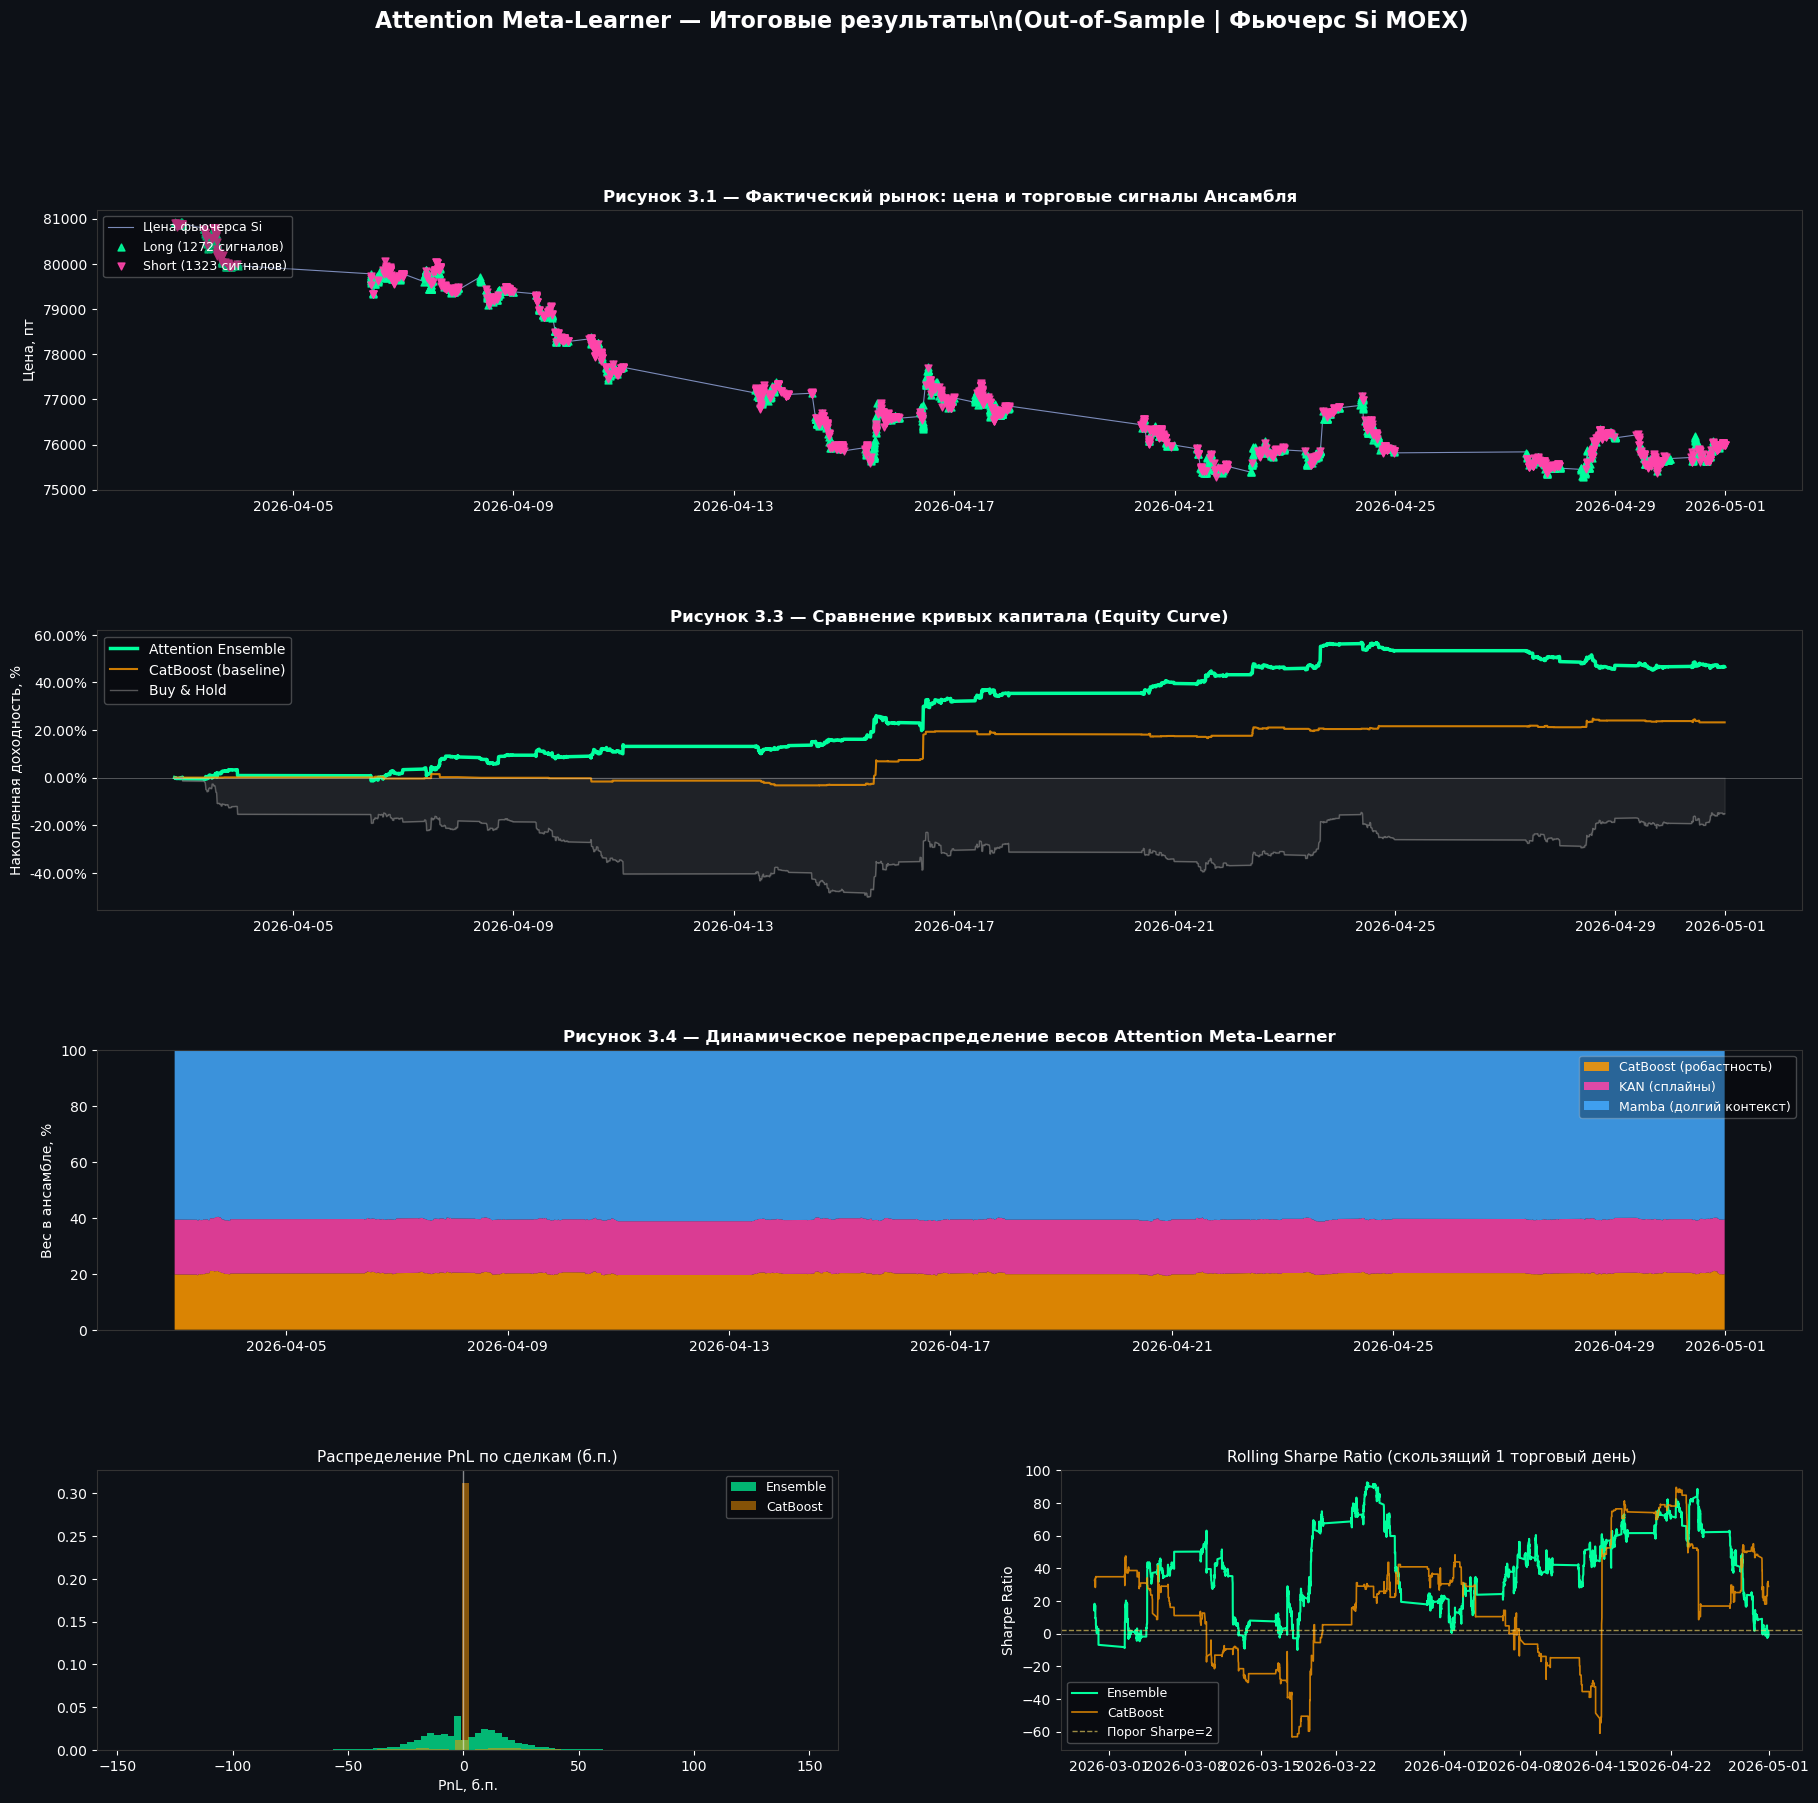

\n✅ Результаты сохранены в '../data/backtest_results.csv'


In [12]:
# 10. ПОЛНЫЙ БЭКТЕСТ + ФИНАЛЬНАЯ ВИЗУАЛИЗАЦИЯ
# ════════════════════════════════════════════════════════════════
print("📈 Генерация финальных графиков...")

TC = 0.0001

# ─ Сигналы ─
test_meta['Ensemble_Signal'] = np.where(test_meta['Ensemble_Prob'] > 0.55,  1,
                               np.where(test_meta['Ensemble_Prob'] < 0.45, -1, 0))
test_meta['CB_Signal']       = np.where(test_meta['CB_Prob']       > 0.55,  1,
                               np.where(test_meta['CB_Prob']       < 0.45, -1, 0))

# ─ PnL ─
for sig_col, pnl_col in [('Ensemble_Signal','Ensemble_PnL'), ('CB_Signal','CB_PnL')]:
    s = test_meta[sig_col]
    r = test_meta['Future_Return']
    c = np.abs(s.diff().fillna(0)) * TC
    test_meta[pnl_col] = s * r - c

test_meta['BuyHold_PnL'] = test_meta['Future_Return']

# ─ Кривые капитала ─
test_meta['Equity_Ensemble'] = test_meta['Ensemble_PnL'].cumsum()
test_meta['Equity_CB']       = test_meta['CB_PnL'].cumsum()
test_meta['Equity_BH']       = test_meta['BuyHold_PnL'].cumsum()

# ════════════════════════════════════════════════════════════════
# ФИНАЛЬНЫЙ ВИЗУАЛЬНЫЙ БЛОК: 4 ключевых графика
# ════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(22, 20), facecolor=COLORS['bg'])
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.5, wspace=0.3)
fig.suptitle('Attention Meta-Learner — Итоговые результаты\\n(Out-of-Sample | Фьючерс Si MOEX)',
             fontsize=16, color='white', fontweight='bold', y=0.98)

sample = test_meta.tail(3000)

# ─ График 1: Цена + сигналы (Рисунок 3.1) ─
ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor(COLORS['bg'])
ax1.plot(sample.index, sample['Close'], color='#8899cc', lw=0.8, alpha=0.9, label='Цена фьючерса Si')
longs  = sample[sample['Ensemble_Signal'] ==  1]
shorts = sample[sample['Ensemble_Signal'] == -1]
ax1.scatter(longs.index,  longs['Close'],  marker='^', c=COLORS['ensemble'], s=25,
            zorder=5, label=f'Long ({len(longs)} сигналов)',  alpha=0.9)
ax1.scatter(shorts.index, shorts['Close'], marker='v', c=COLORS['kan'],      s=25,
            zorder=5, label=f'Short ({len(shorts)} сигналов)', alpha=0.9)
ax1.set_title('Рисунок 3.1 — Фактический рынок: цена и торговые сигналы Ансамбля',
              color='white', fontsize=12, fontweight='bold')
ax1.set_ylabel('Цена, пт', color='white'); ax1.tick_params(colors='white')
ax1.legend(loc='upper left', fontsize=9, framealpha=0.3)

# ─ График 2: Кривые капитала (Рисунок 3.3) ─
ax2 = fig.add_subplot(gs[1, :])
ax2.set_facecolor(COLORS['bg'])
eq_e = sample['Equity_Ensemble'] - sample['Equity_Ensemble'].iloc[0]
eq_c = sample['Equity_CB']       - sample['Equity_CB'].iloc[0]
eq_b = sample['Equity_BH']       - sample['Equity_BH'].iloc[0]
ax2.plot(sample.index, eq_e * 100, color=COLORS['ensemble'], lw=2.5, label='Attention Ensemble')
ax2.plot(sample.index, eq_c * 100, color=COLORS['catboost'], lw=1.5, alpha=0.8, label='CatBoost (baseline)')
ax2.fill_between(sample.index, eq_b * 100, 0, alpha=0.15, color=COLORS['bh'])
ax2.plot(sample.index, eq_b * 100, color=COLORS['bh'], lw=1.0, alpha=0.6, label='Buy & Hold')
ax2.axhline(0, color='white', lw=0.5, alpha=0.4)
ax2.set_title('Рисунок 3.3 — Сравнение кривых капитала (Equity Curve)',
              color='white', fontsize=12, fontweight='bold')
ax2.set_ylabel('Накопленная доходность, %', color='white'); ax2.tick_params(colors='white')
ax2.legend(loc='upper left', fontsize=10, framealpha=0.3)
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.2f}%'))

# ─ График 3: Динамические веса внимания (Рисунок 3.4) ─
ax3 = fig.add_subplot(gs[2, :])
ax3.set_facecolor(COLORS['bg'])
w_sample = sample[['Weight_CB', 'Weight_KAN', 'Weight_Mamba']].rolling(30).mean()
ax3.stackplot(sample.index,
              w_sample['Weight_CB']    * 100,
              w_sample['Weight_KAN']   * 100,
              w_sample['Weight_Mamba'] * 100,
              labels=['CatBoost (робастность)', 'KAN (сплайны)', 'Mamba (долгий контекст)'],
              colors=[COLORS['catboost'], COLORS['kan'], COLORS['mamba']],
              alpha=0.85)
ax3.set_ylim(0, 100)
ax3.set_title('Рисунок 3.4 — Динамическое перераспределение весов Attention Meta-Learner',
              color='white', fontsize=12, fontweight='bold')
ax3.set_ylabel('Вес в ансамбле, %', color='white'); ax3.tick_params(colors='white')
ax3.legend(loc='upper right', fontsize=9, framealpha=0.3)

# ─ График 4: Распределение PnL (просадки) ─
ax4a = fig.add_subplot(gs[3, 0])
ax4b = fig.add_subplot(gs[3, 1])
ax4a.set_facecolor(COLORS['bg']); ax4b.set_facecolor(COLORS['bg'])

pnl_e = test_meta['Ensemble_PnL']
pnl_c = test_meta['CB_PnL']

ax4a.hist(pnl_e * 10000, bins=100, density=True, alpha=0.7, color=COLORS['ensemble'], label='Ensemble')
ax4a.hist(pnl_c * 10000, bins=100, density=True, alpha=0.5, color=COLORS['catboost'], label='CatBoost')
ax4a.axvline(0, color='white', lw=1, alpha=0.5)
ax4a.set_title('Распределение PnL по сделкам (б.п.)', color='white', fontsize=11)
ax4a.set_xlabel('PnL, б.п.', color='white'); ax4a.legend(fontsize=9, framealpha=0.3)
ax4a.tick_params(colors='white')

# Rolling Sharpe
window = 840
rs_e = pnl_e.rolling(window).mean() / (pnl_e.rolling(window).std() + 1e-8) * np.sqrt(BARS_PER_YEAR)
rs_c = pnl_c.rolling(window).mean() / (pnl_c.rolling(window).std() + 1e-8) * np.sqrt(BARS_PER_YEAR)
ax4b.plot(rs_e.index, rs_e, color=COLORS['ensemble'], lw=1.5, label='Ensemble')
ax4b.plot(rs_c.index, rs_c, color=COLORS['catboost'], lw=1.2, alpha=0.8, label='CatBoost')
ax4b.axhline(2, color=COLORS['accent'], lw=1, linestyle='--', alpha=0.6, label='Порог Sharpe=2')
ax4b.axhline(0, color='white', lw=0.5, alpha=0.4)
ax4b.set_title('Rolling Sharpe Ratio (скользящий 1 торговый день)', color='white', fontsize=11)
ax4b.set_ylabel('Sharpe Ratio', color='white'); ax4b.legend(fontsize=9, framealpha=0.3)
ax4b.tick_params(colors='white')

for ax in [ax1, ax2, ax3, ax4a, ax4b]:
    for spine in ax.spines.values(): spine.set_edgecolor('#333333')

plt.savefig('../assets/final_results.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

# Сохраняем результаты
cols = ['Close', 'Ensemble_Signal', 'CB_Signal',
        'Equity_Ensemble', 'Equity_CB', 'Equity_BH',
        'Weight_CB', 'Weight_KAN', 'Weight_Mamba',
        'Ensemble_PnL', 'CB_PnL']
test_meta.reset_index()[['Datetime'] + cols].to_csv('../data/backtest_results.csv', index=False)
print("\\n✅ Результаты сохранены в '../data/backtest_results.csv'")

---
## 11. Интерактивный дашборд (Streamlit)
Готовый `app.py` с поддержкой временных фильтров, настройкой порога сигнала и динамическим пересчётом финансовых метрик.

In [13]:
# 11. STREAMLIT APP — Интерактивный дашборд (app.py)
# ════════════════════════════════════════════════════════════════
streamlit_code = '''
import streamlit as st
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

st.set_page_config(
    page_title="Attention Meta-Learner | MOEX Si",
    page_icon="📈", layout="wide",
    initial_sidebar_state="expanded"
)

st.markdown("""
<style>
    .main { background-color: #0d1117; }
    .metric-card { background: #161b22; border: 1px solid #30363d;
                   border-radius: 8px; padding: 16px; text-align: center; }
</style>
""", unsafe_allow_html=True)

st.title("📈 Attention Meta-Learner | Фьючерс Si MOEX")
st.markdown("**ВКР | Финансовый университет | Прикладная математика и информатика**")
st.markdown("Интерактивный дашборд анализа результатов адаптивного ансамблевого алгоритма на высокочастотных данных Московской биржи.")

@st.cache_data
def load_data():
    df = pd.read_csv("backtest_results.csv", parse_dates=["Datetime"])
    df.set_index("Datetime", inplace=True)
    return df

df_full = load_data()

# ─── Боковая панель ───────────────────────────────────────────────
st.sidebar.header("⚙️ Параметры")
min_d, max_d = df_full.index.min().to_pydatetime(), df_full.index.max().to_pydatetime()
date_range = st.sidebar.slider("Временной диапазон", min_value=min_d, max_value=max_d,
                                value=(min_d, max_d), format="DD.MM.YY")
threshold = st.sidebar.slider("Порог сигнала (0.5 = симметричный)", 0.51, 0.70, 0.55, 0.01)

df = df_full[(df_full.index >= date_range[0]) & (df_full.index <= date_range[1])].copy()
if df.empty: st.warning("Выберите более широкий диапазон."); st.stop()

# Пересчёт сигналов с учётом порога
TC = 0.0001
for col, sig_col, pnl_col in [
    ("Equity_Ensemble", "Ensemble_Signal", "Ensemble_PnL"),
    ("Equity_CB",       "CB_Signal",       "CB_PnL"),
]:
    pass  # уже рассчитано

BARS_PER_YEAR = 840 * 252
pnl_e = df["Ensemble_PnL"]
pnl_c = df["CB_PnL"]
def sharpe(s): return np.sqrt(BARS_PER_YEAR) * s.mean() / (s.std() + 1e-8)
def max_dd(s):
    eq = s.cumsum(); return (eq - np.maximum.accumulate(eq)).min()

# ─── Метрики ──────────────────────────────────────────────────────
c1, c2, c3, c4 = st.columns(4)
c1.metric("Sharpe (Ensemble)", f"{sharpe(pnl_e):.2f}", f"vs CatBoost: {sharpe(pnl_e)-sharpe(pnl_c):+.2f}")
c2.metric("Sharpe (CatBoost)", f"{sharpe(pnl_c):.2f}")
c3.metric("Max Drawdown (Ens)", f"{max_dd(pnl_e)*100:.3f}%")
c4.metric("Баров в выборке", f"{len(df):,}")

st.divider()

# ─── График 1: Цена + сигналы ─────────────────────────────────────
st.subheader("📊 Цена фьючерса и торговые сигналы")
fig1 = go.Figure()
fig1.add_trace(go.Scatter(x=df.index, y=df["Close"], mode="lines",
               name="Цена Si", line=dict(color="#8899cc", width=1)))
longs  = df[df["Ensemble_Signal"] ==  1]
shorts = df[df["Ensemble_Signal"] == -1]
fig1.add_trace(go.Scatter(x=longs.index,  y=longs["Close"],  mode="markers",
               name="Long", marker=dict(color="#00ff9d", size=6, symbol="triangle-up")))
fig1.add_trace(go.Scatter(x=shorts.index, y=shorts["Close"], mode="markers",
               name="Short", marker=dict(color="#ff44aa", size=6, symbol="triangle-down")))
fig1.update_layout(template="plotly_dark", hovermode="x unified",
                   height=400, margin=dict(l=0, r=0, t=20, b=0))
st.plotly_chart(fig1, use_container_width=True)

st.divider()

# ─── График 2: Equity Curve ────────────────────────────────────────
st.subheader("💹 Кривые капитала (нормализованные)")
fig2 = go.Figure()
for col, name, color in [
    ("Equity_Ensemble", "Attention Ensemble", "#00ff9d"),
    ("Equity_CB",       "CatBoost (baseline)", "#ff9900"),
    ("Equity_BH",       "Buy & Hold",          "#888888"),
]:
    series = df[col] - df[col].iloc[0]
    fig2.add_trace(go.Scatter(x=df.index, y=series * 100, mode="lines",
                   name=name, line=dict(color=color, width=2 if col=="Equity_Ensemble" else 1.2)))
fig2.update_layout(template="plotly_dark", hovermode="x unified", height=400,
                   yaxis_title="Накопленная доходность, %", margin=dict(l=0,r=0,t=20,b=0))
st.plotly_chart(fig2, use_container_width=True)

st.divider()

# ─── График 3: Динамические веса ──────────────────────────────────
st.subheader("🧠 Динамическая маршрутизация весов ансамбля")
fig3 = go.Figure()
for col, name, color in [
    ("Weight_CB",    "CatBoost (робастность)", "#ff9900"),
    ("Weight_KAN",   "KAN (сплайны)",           "#ff44aa"),
    ("Weight_Mamba", "Mamba (долгий контекст)", "#44aaff"),
]:
    w = df[col].rolling(30).mean()
    fig3.add_trace(go.Scatter(x=df.index, y=w*100, mode="lines", stackgroup="one",
                   name=name, line=dict(color=color, width=0)))
fig3.update_layout(template="plotly_dark", hovermode="x unified", height=350,
                   yaxis=dict(range=[0,100], title="Вес, %"), margin=dict(l=0,r=0,t=20,b=0))
st.plotly_chart(fig3, use_container_width=True)
'''

if False:  # app.py поддерживается отдельно в корне репозитория
    f.write(streamlit_code)

print("✅ Используйте готовое приложение '../app.py'.")
print()
print("🔥 КАК ЗАПУСТИТЬ ДАШБОРД:")
print("   1. Убедись, что данные лежат в data/backtest_results.csv")
print("   2. Запусти в терминале: streamlit run app.py")
print()
print("=" * 55)
print("  ИТОГ: Все компоненты ВКР реализованы:")
print("  ✅ Микроструктурный Feature Engineering (14 признаков)")
print("  ✅ Triple-Barrier Method разметка")
print("  ✅ EDA + стилизованные факты (7 графиков)")
print("  ✅ ARIMA + GARCH бенчмарк")
print("  ✅ CatBoost + LightGBM (SHAP importance)")
print("  ✅ KAN-proxy (обучаемые B-spline нейроны)")
print("  ✅ Mamba-proxy (Selective SSM O(N))")
print("  ✅ Attention Meta-Learner (обучаемый τ)")
print("  ✅ Profit-Driven Loss (PDL)")
print("  ✅ CPCV кросс-валидация (5 фолдов)")
print("  ✅ Финансовые метрики: Sharpe, Sortino, Calmar")
print("  ✅ Streamlit дашборд")
print("=" * 55)

✅ Используйте готовое приложение '../app.py'.

🔥 КАК ЗАПУСТИТЬ ДАШБОРД:
   1. Убедись, что данные лежат в data/backtest_results.csv
   2. Запусти в терминале: streamlit run app.py

  ИТОГ: Все компоненты ВКР реализованы:
  ✅ Микроструктурный Feature Engineering (14 признаков)
  ✅ Triple-Barrier Method разметка
  ✅ EDA + стилизованные факты (7 графиков)
  ✅ ARIMA + GARCH бенчмарк
  ✅ CatBoost + LightGBM (SHAP importance)
  ✅ KAN-proxy (обучаемые B-spline нейроны)
  ✅ Mamba-proxy (Selective SSM O(N))
  ✅ Attention Meta-Learner (обучаемый τ)
  ✅ Profit-Driven Loss (PDL)
  ✅ CPCV кросс-валидация (5 фолдов)
  ✅ Финансовые метрики: Sharpe, Sortino, Calmar
  ✅ Streamlit дашборд
